In [7]:
import pandas as pd
import statsmodels.api as sm

# 데이터 불러오기
df = pd.read_csv("../data/train_dataset.csv")

# 필요한 컬럼만 선택
analysis_cols = [
    "추정일간클릭수", "1개당가격", "최근4주클릭수_비율", "weekday", "pum_name"
]
df = df[analysis_cols].dropna()

# ✅ 숫자형 변환
for col in ["추정일간클릭수", "1개당가격", "최근4주클릭수_비율"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ✅ 범주형 변수 더미 처리
df = pd.get_dummies(df, columns=["pum_name", "weekday"], drop_first=True)

# ✅ 모든 컬럼을 float으로 변환
df = df.astype(float)

# 종속변수와 독립변수 분리
y = df["추정일간클릭수"]
X = df.drop("추정일간클릭수", axis=1)

# 상수항 추가
X = sm.add_constant(X)

# 회귀분석 실행
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                추정일간클릭수   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     6188.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:49:04   Log-Likelihood:            -1.6860e+05
No. Observations:               25186   AIC:                         3.372e+05
Df Residuals:                   25172   BIC:                         3.373e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -31.4786      4.15

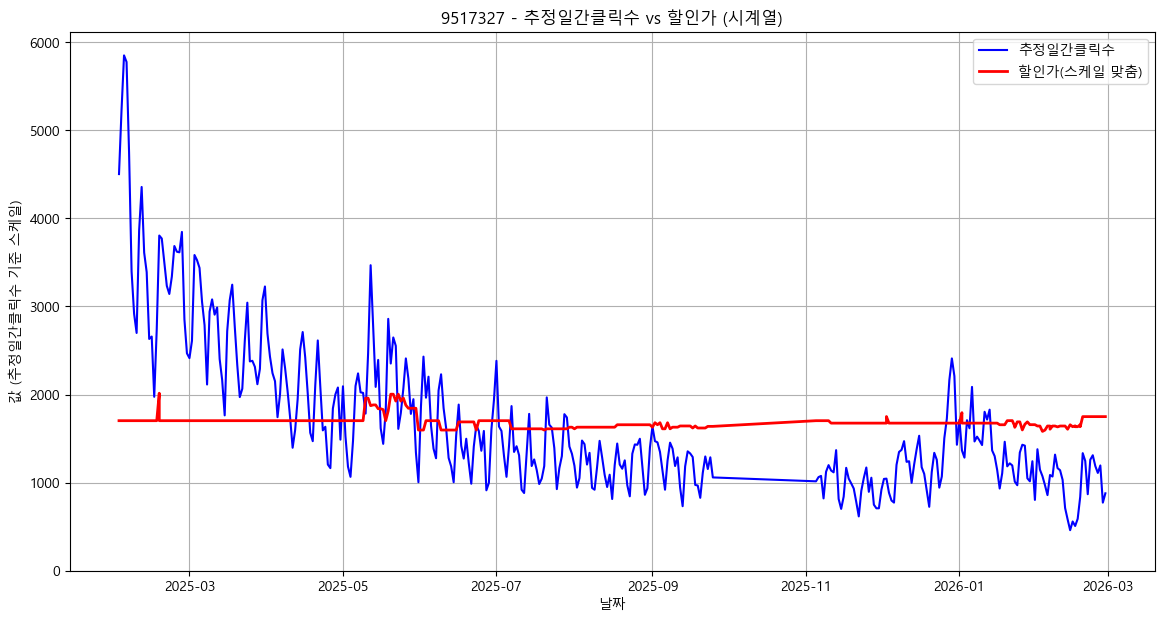

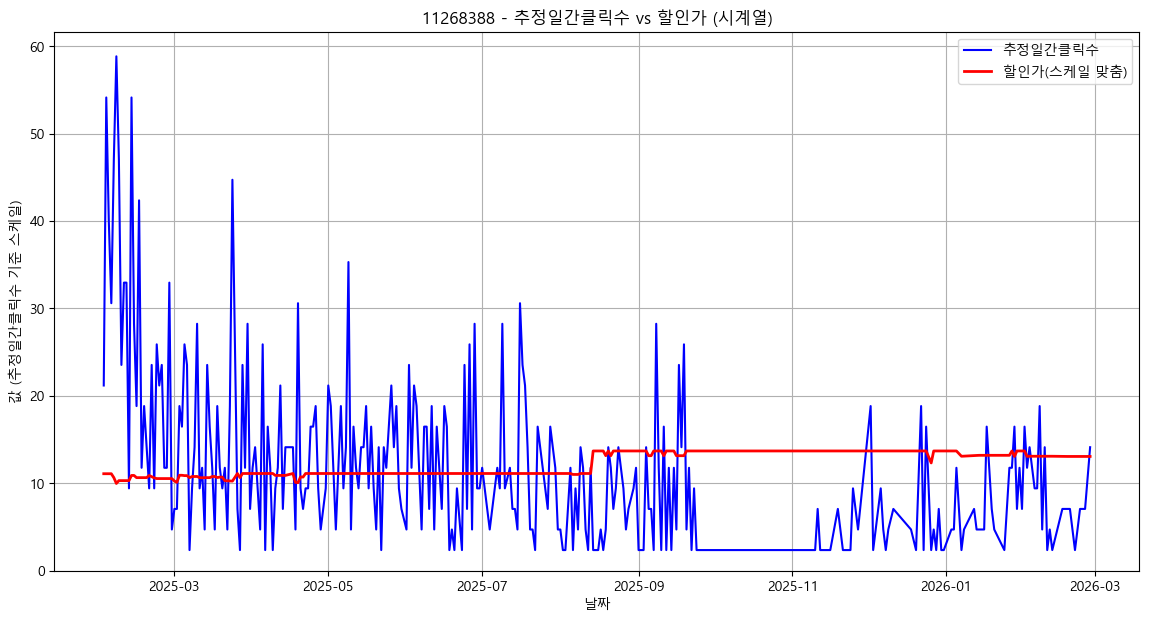

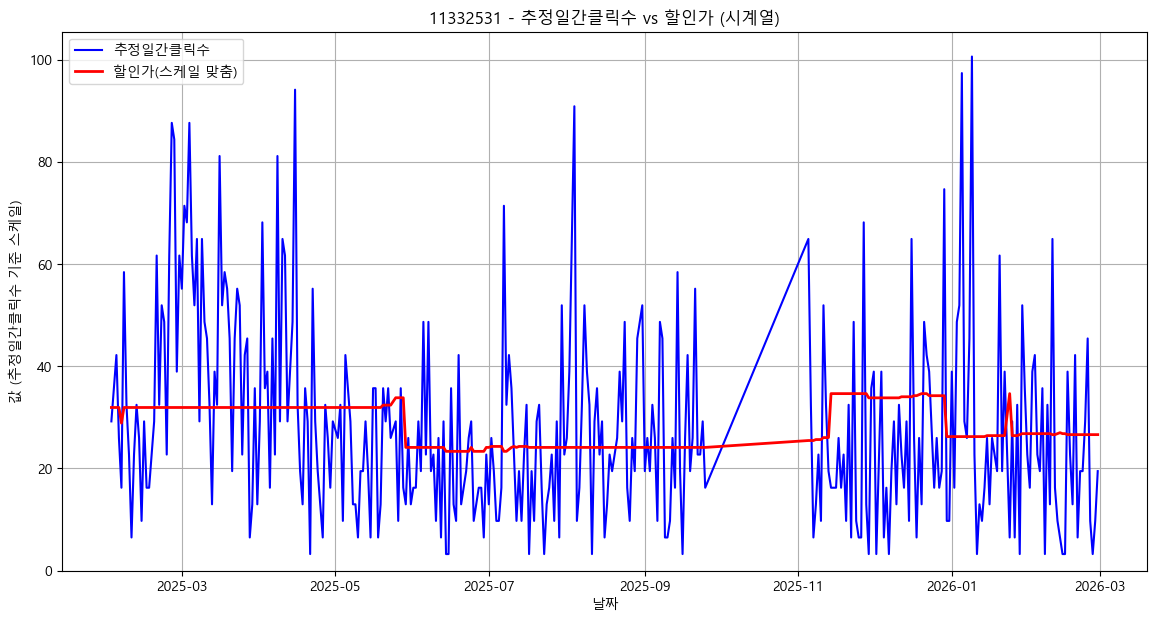

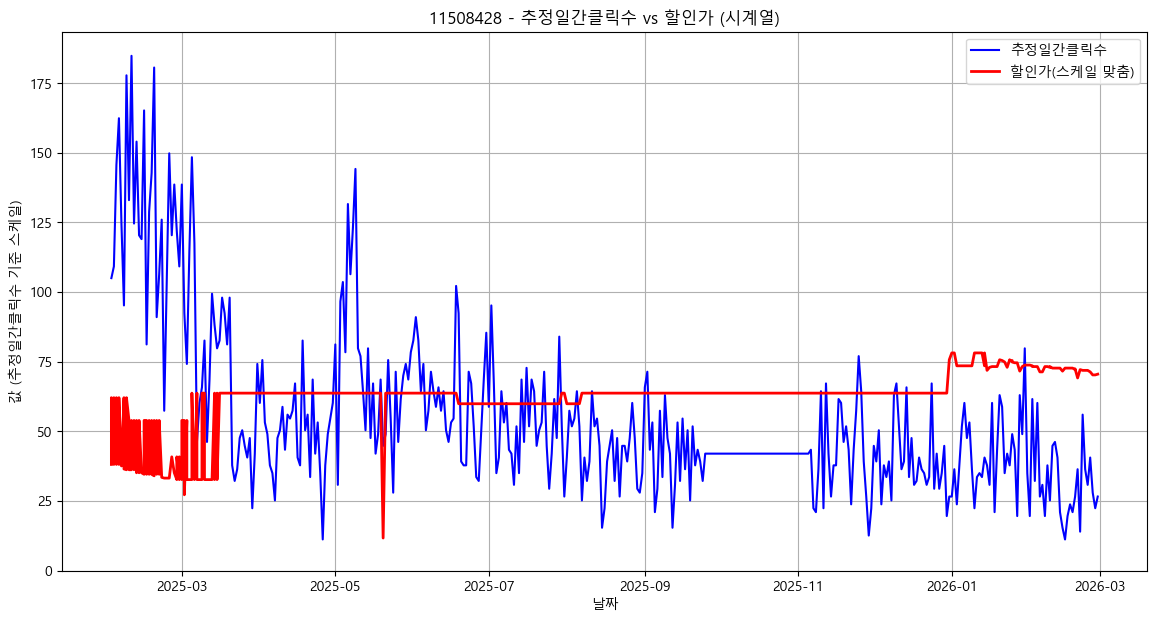

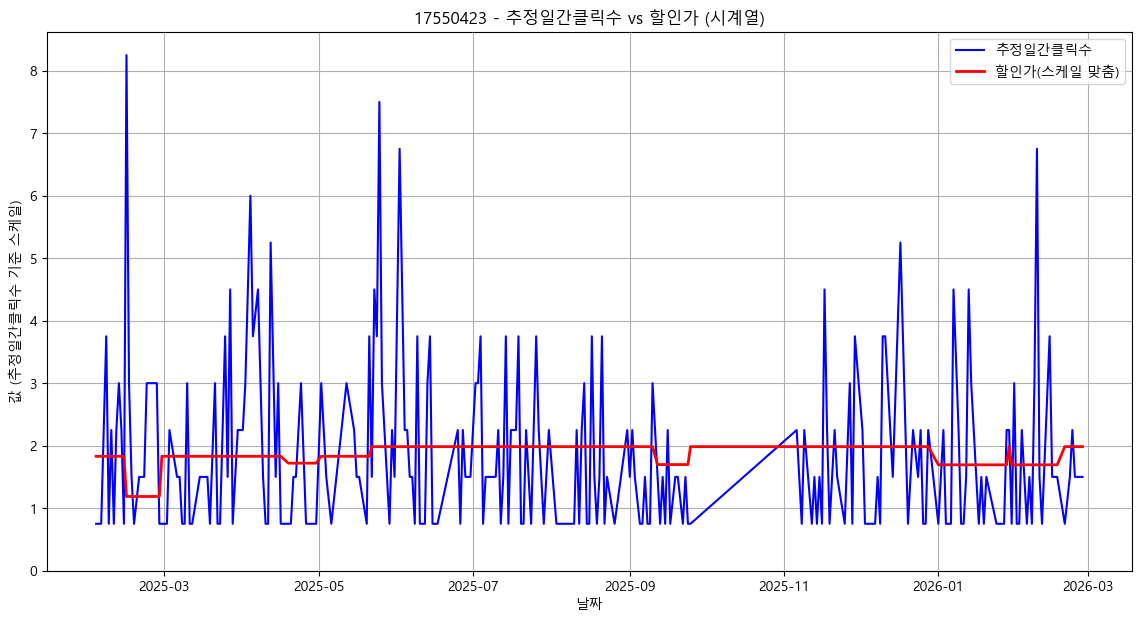

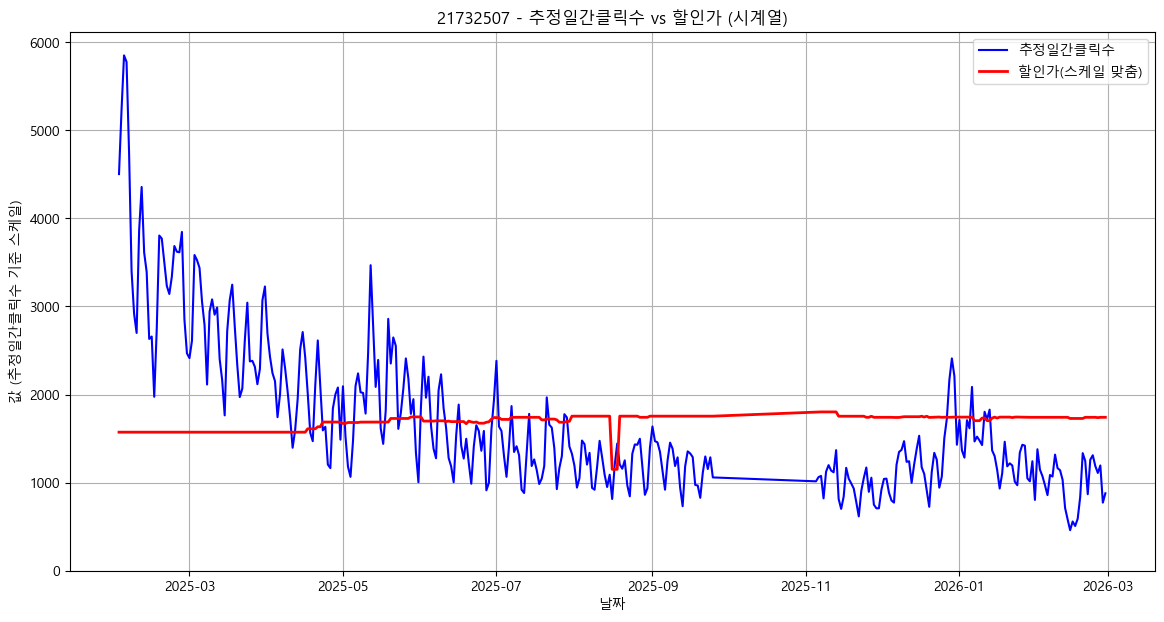

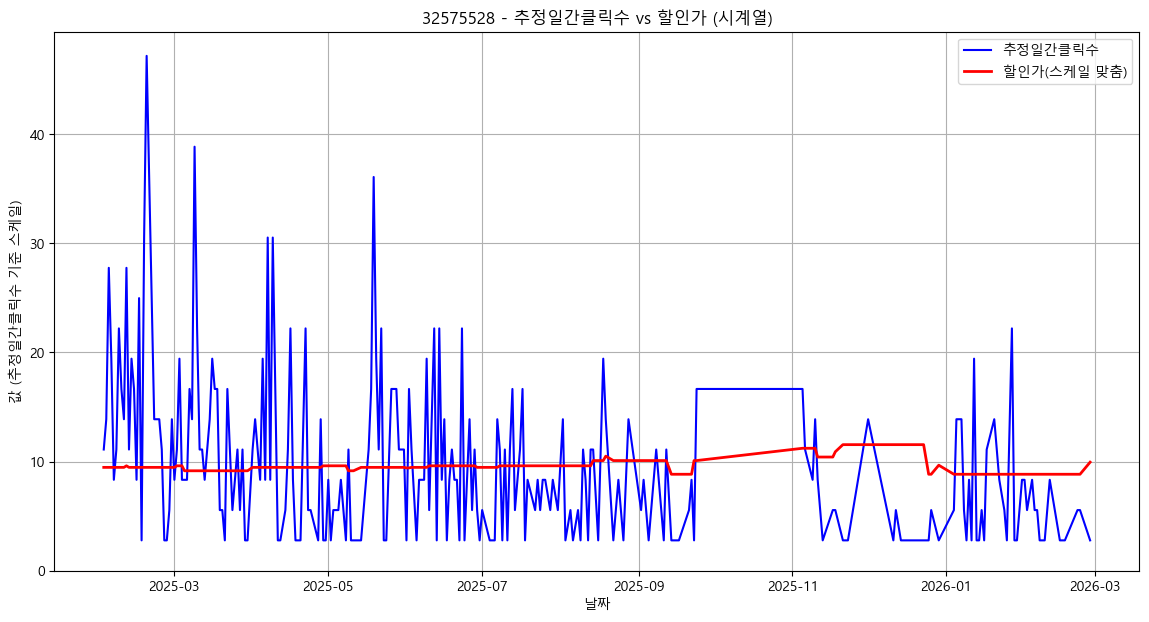

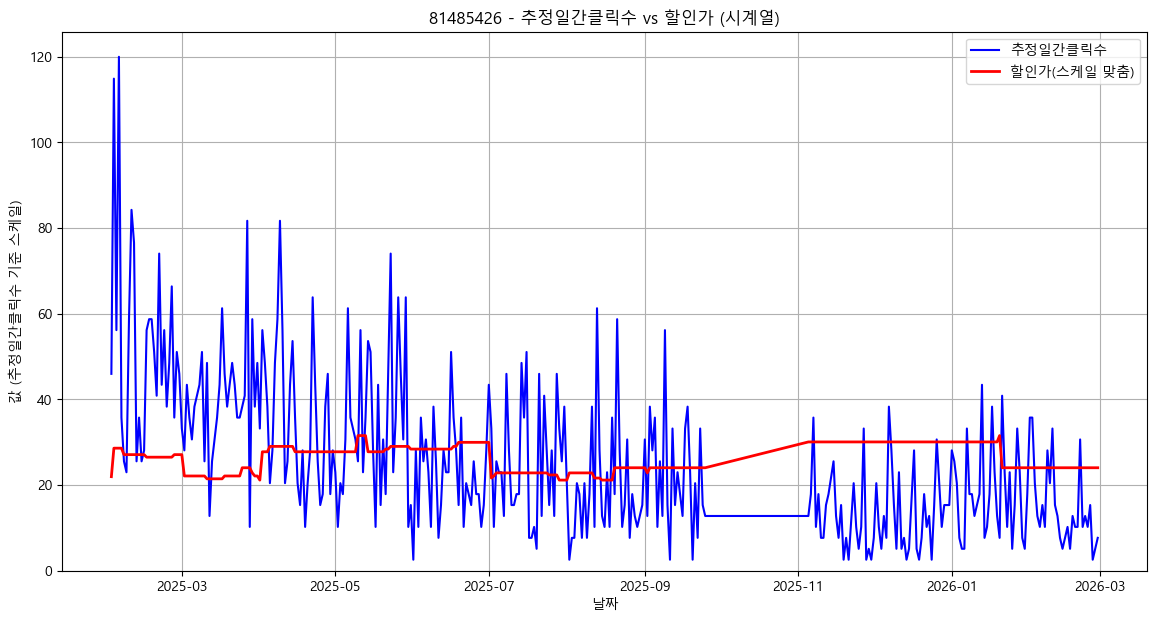

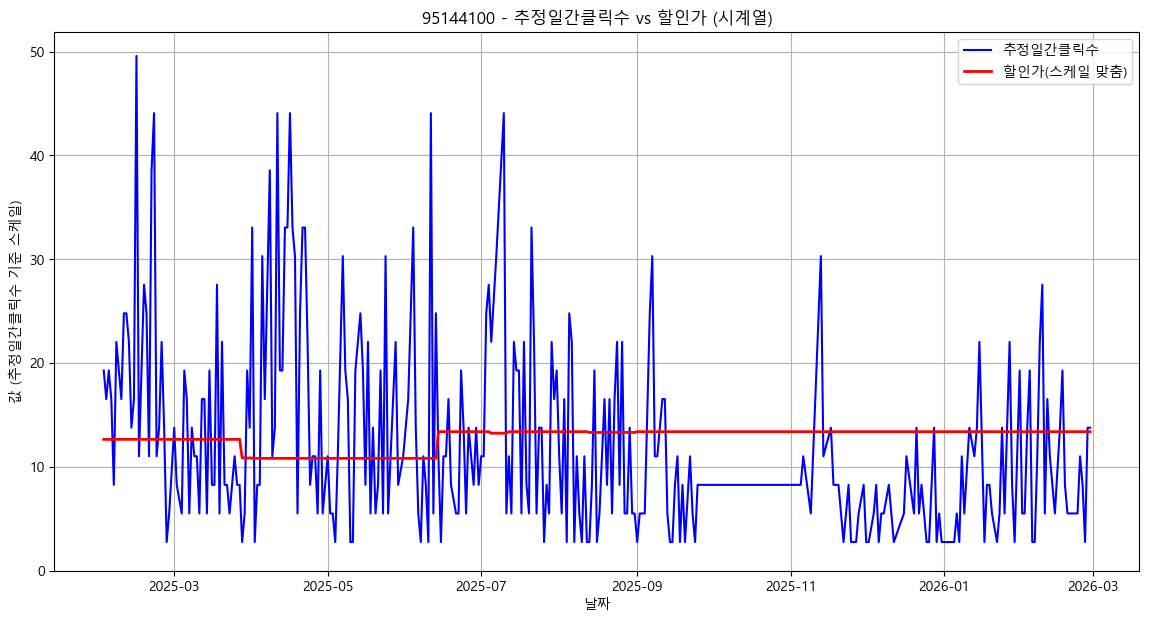

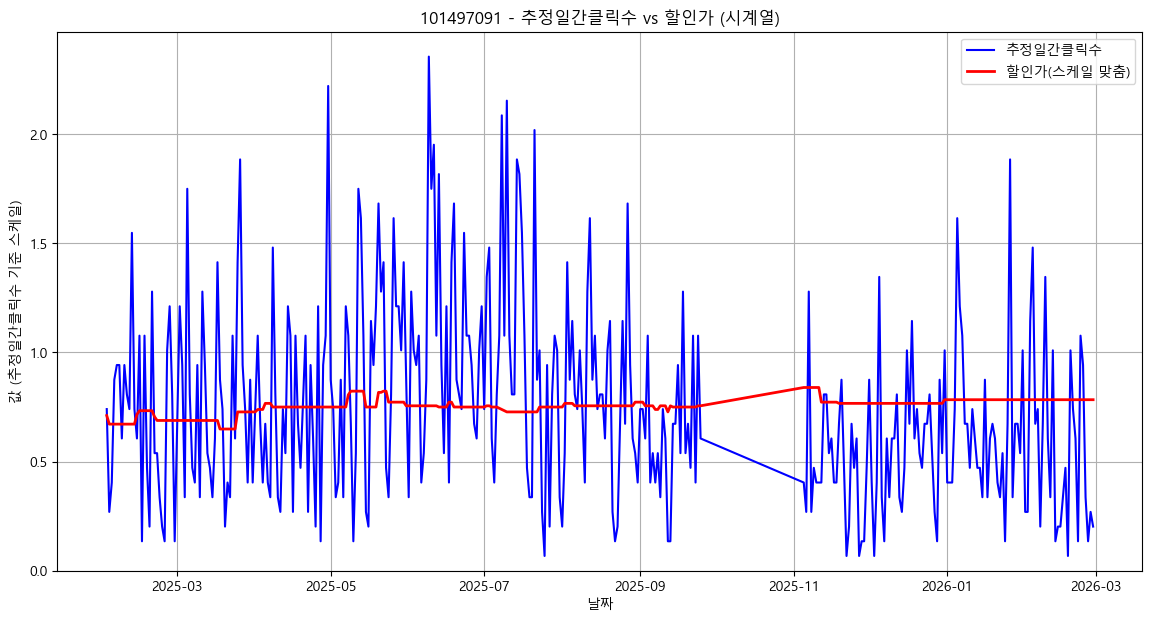

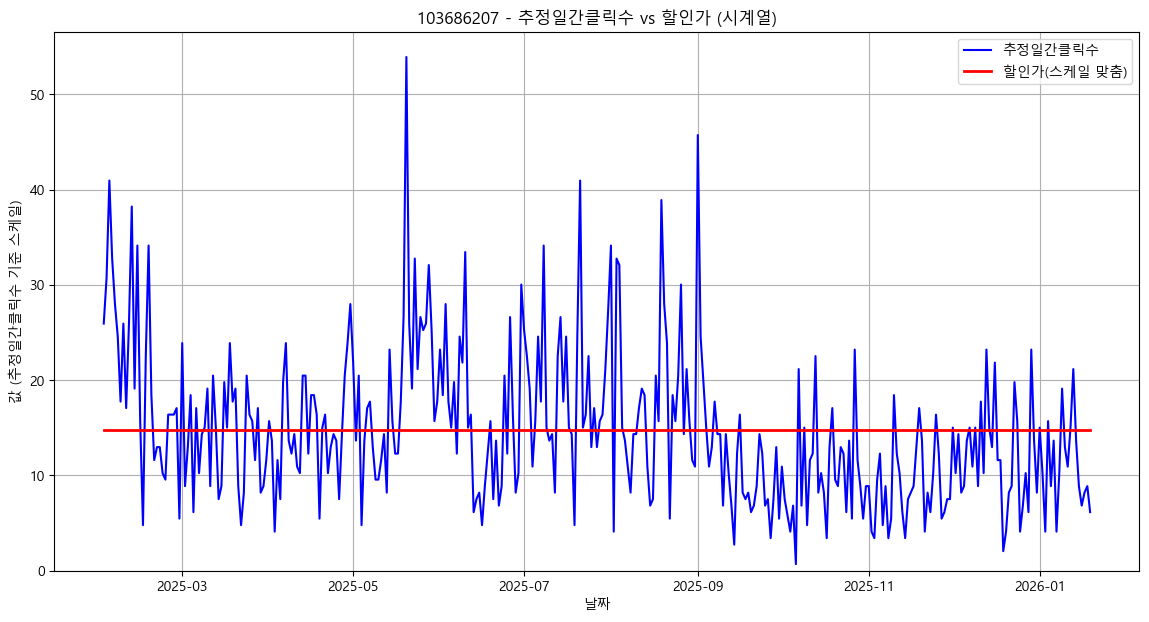

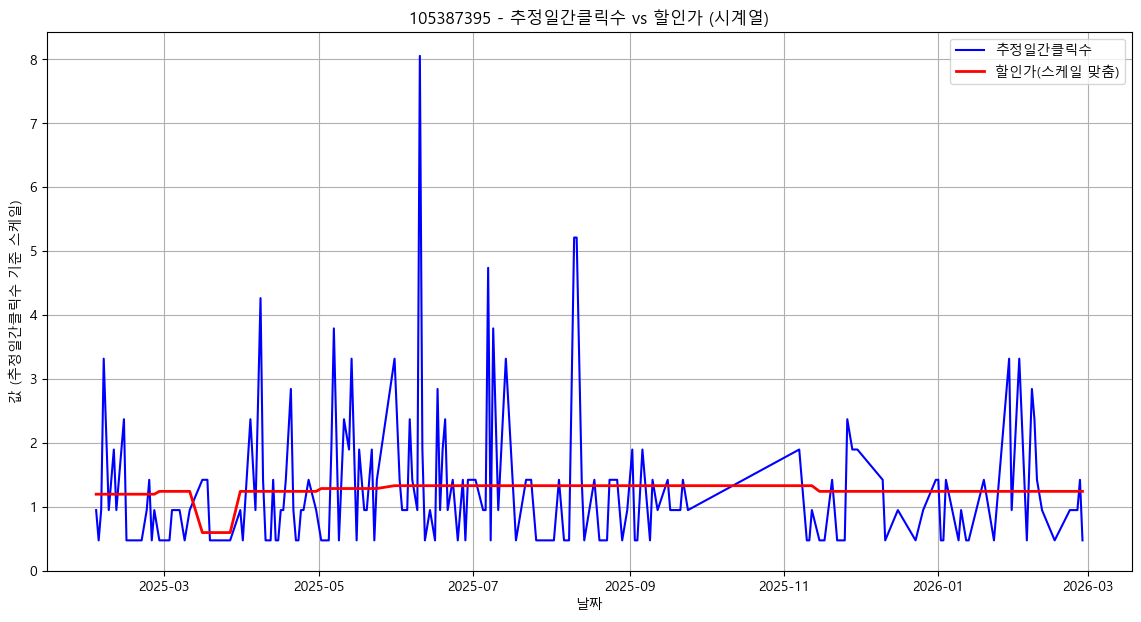

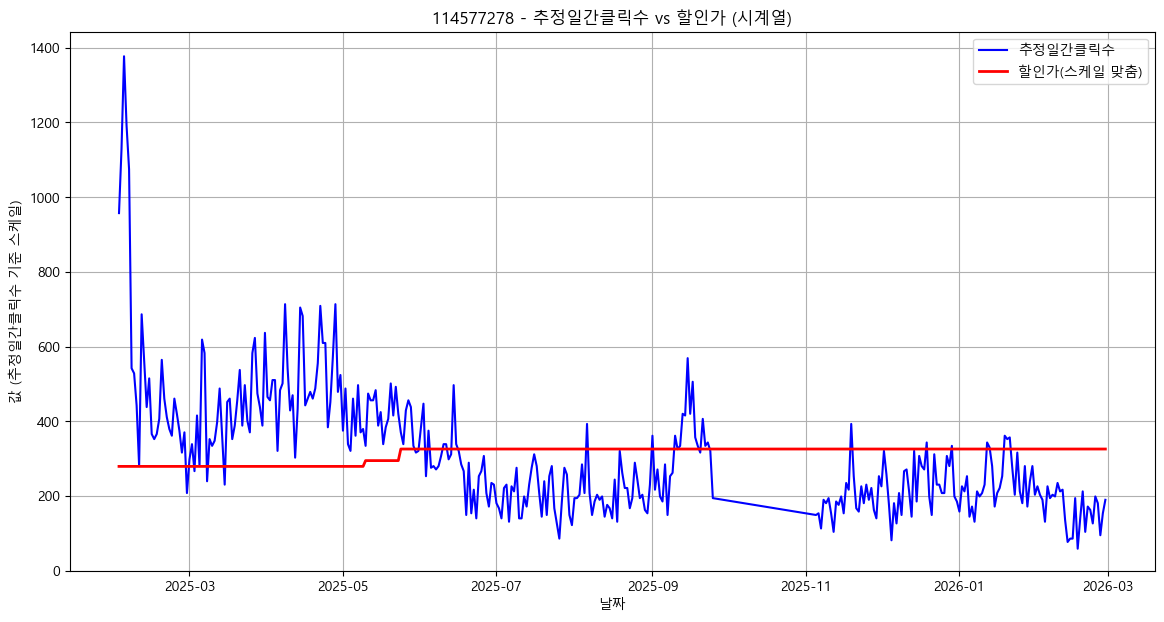

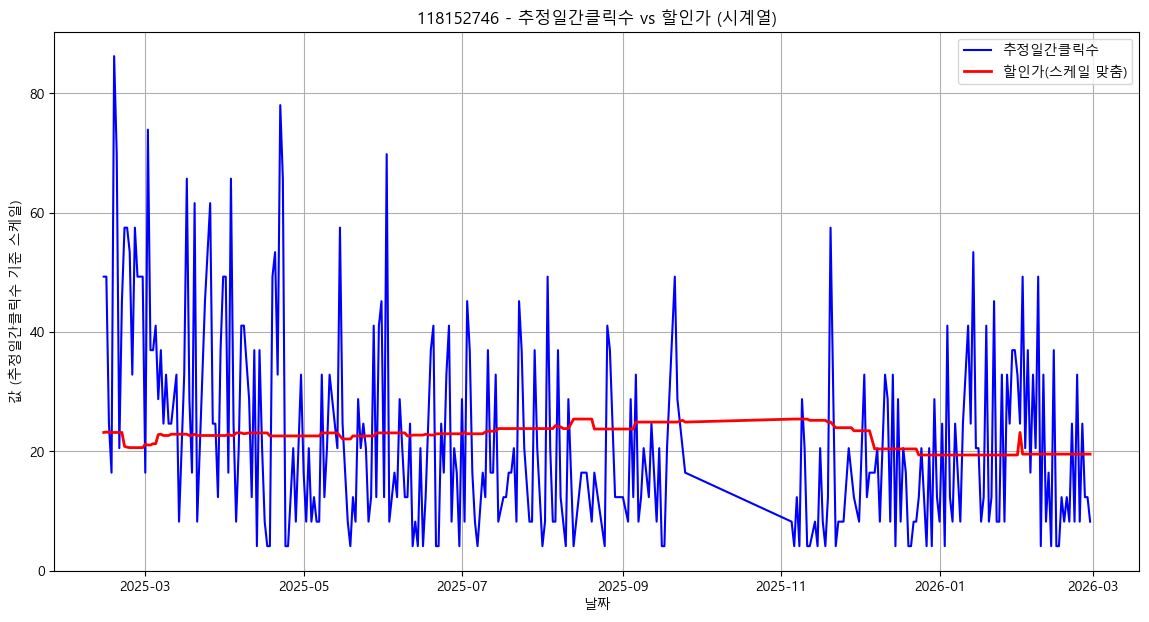

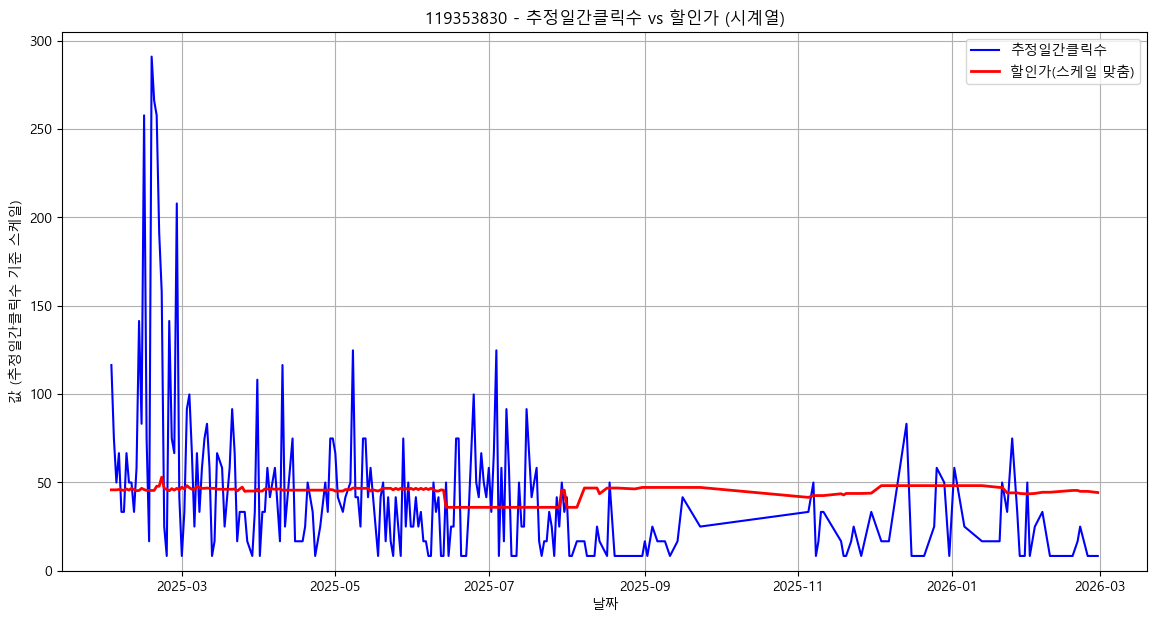

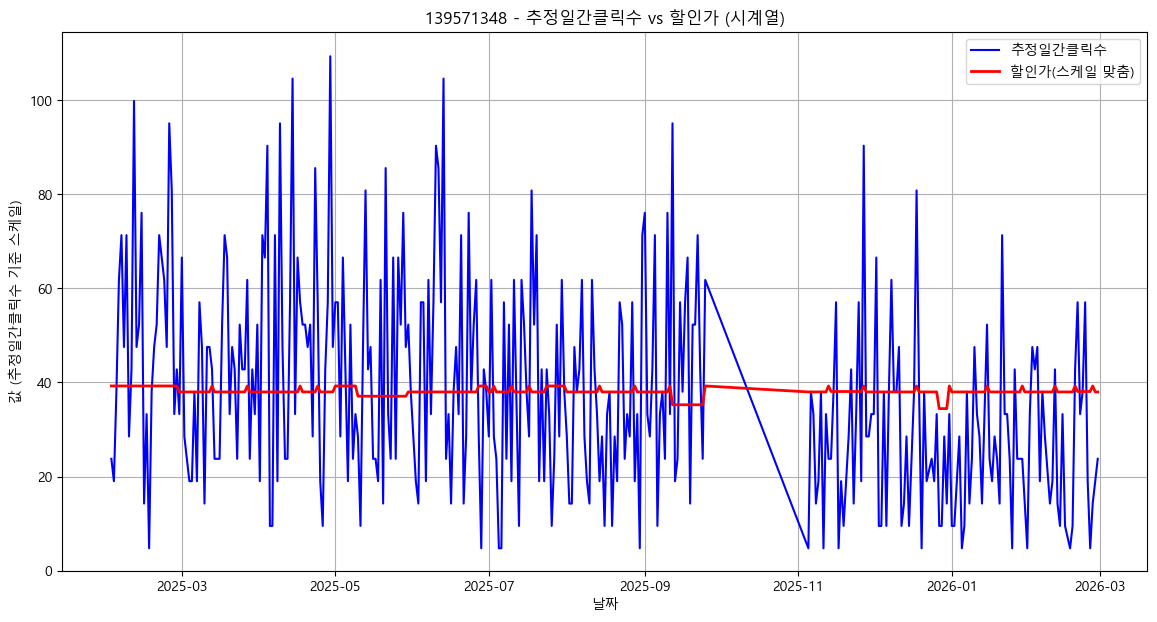

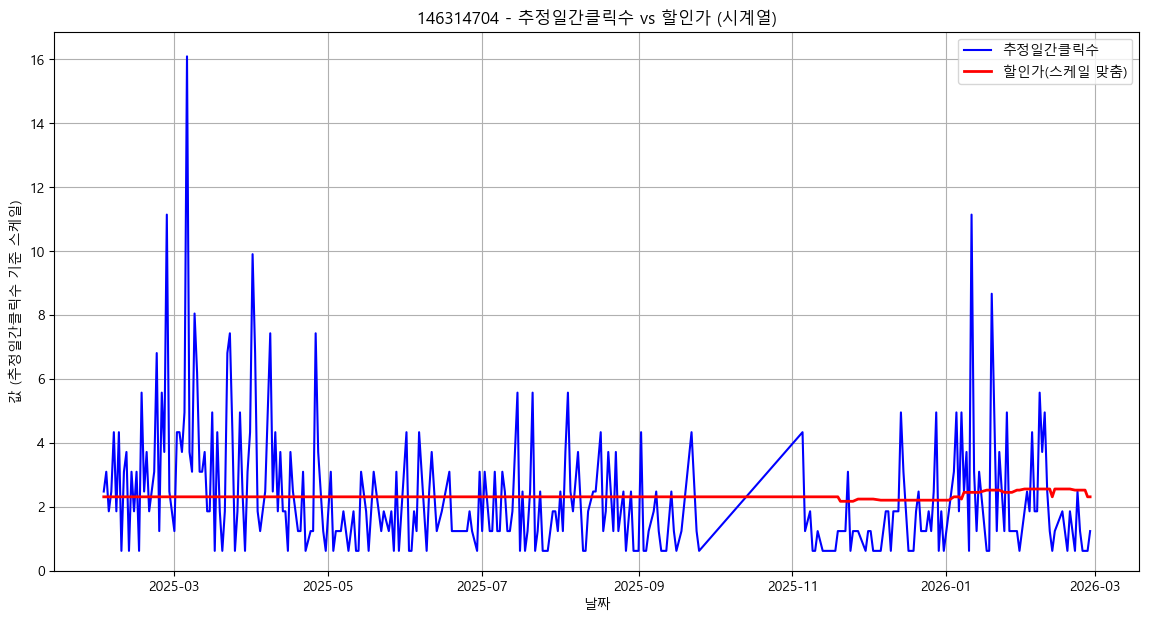

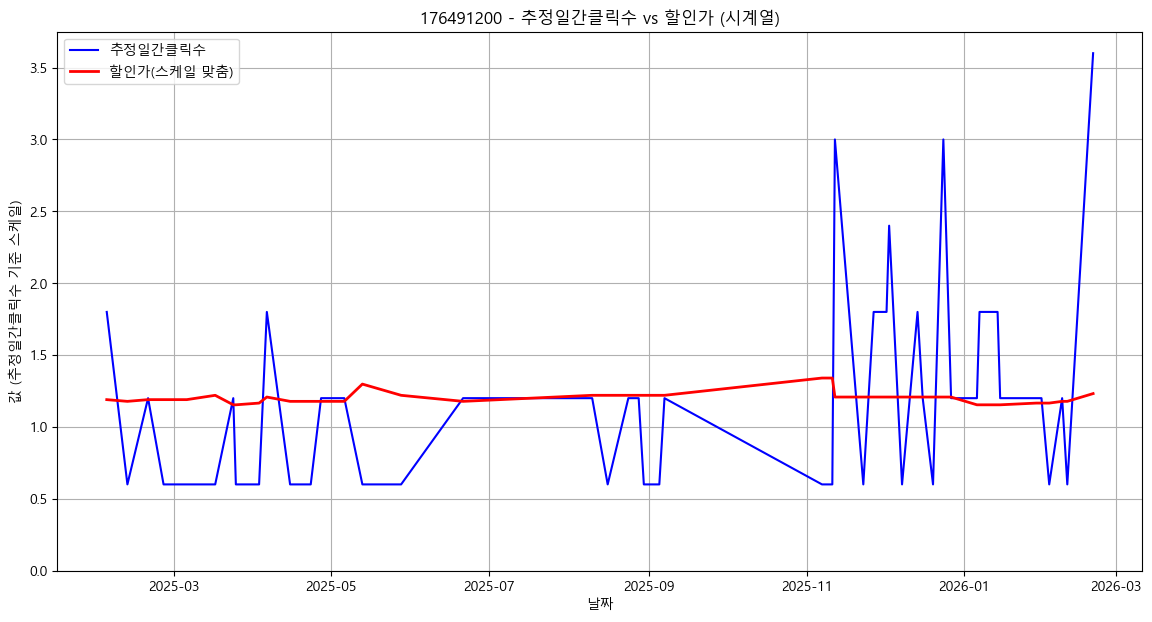

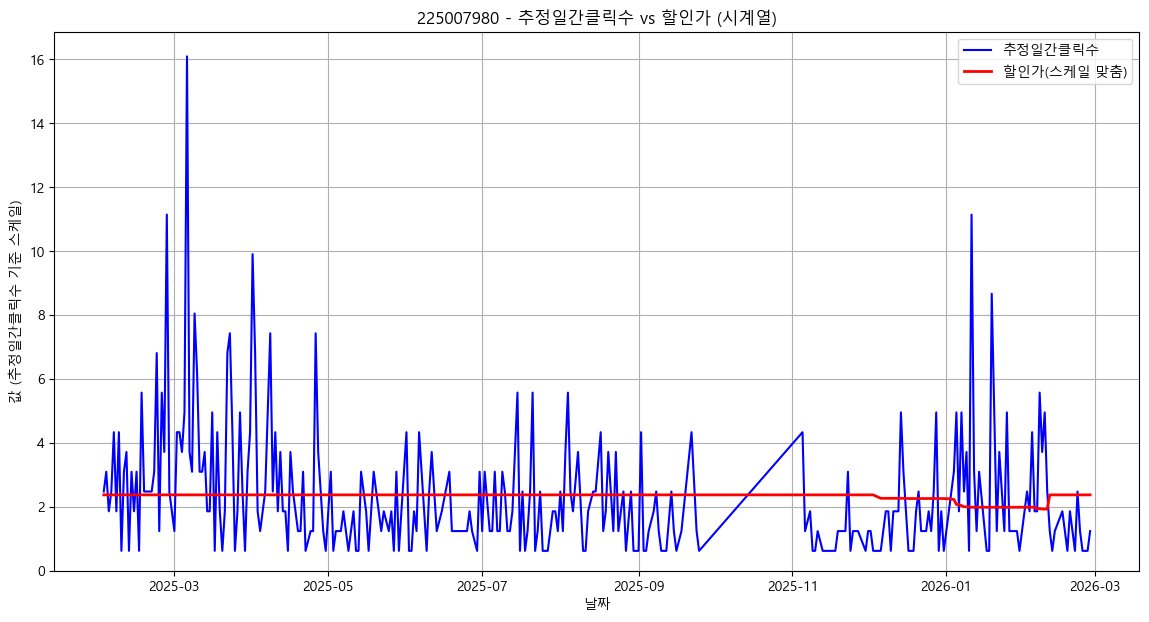

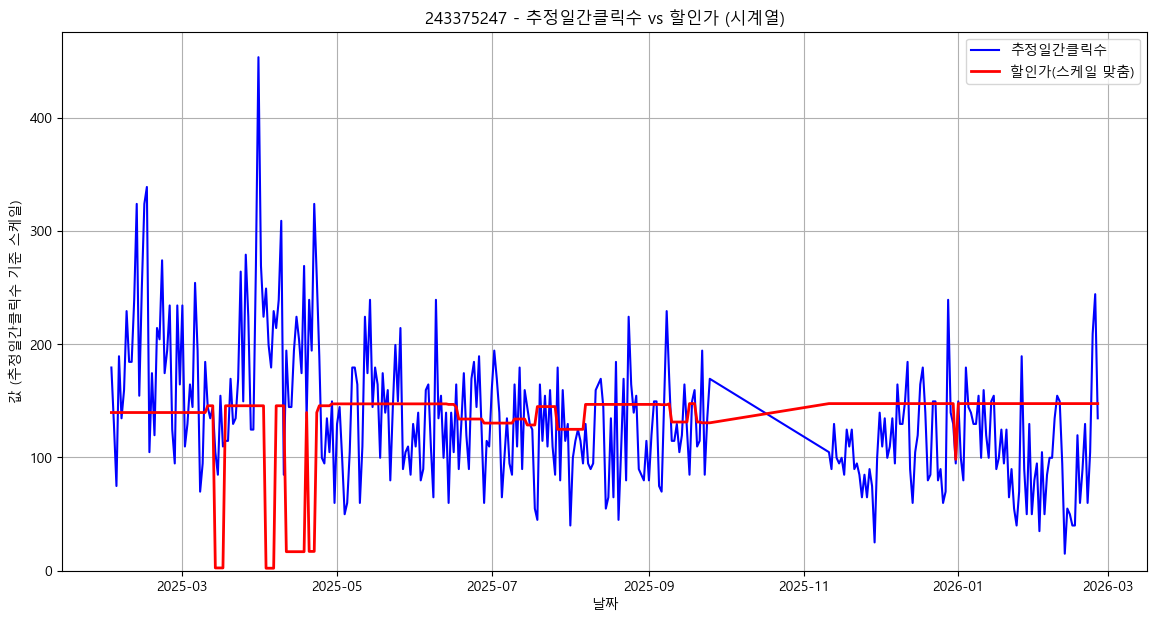

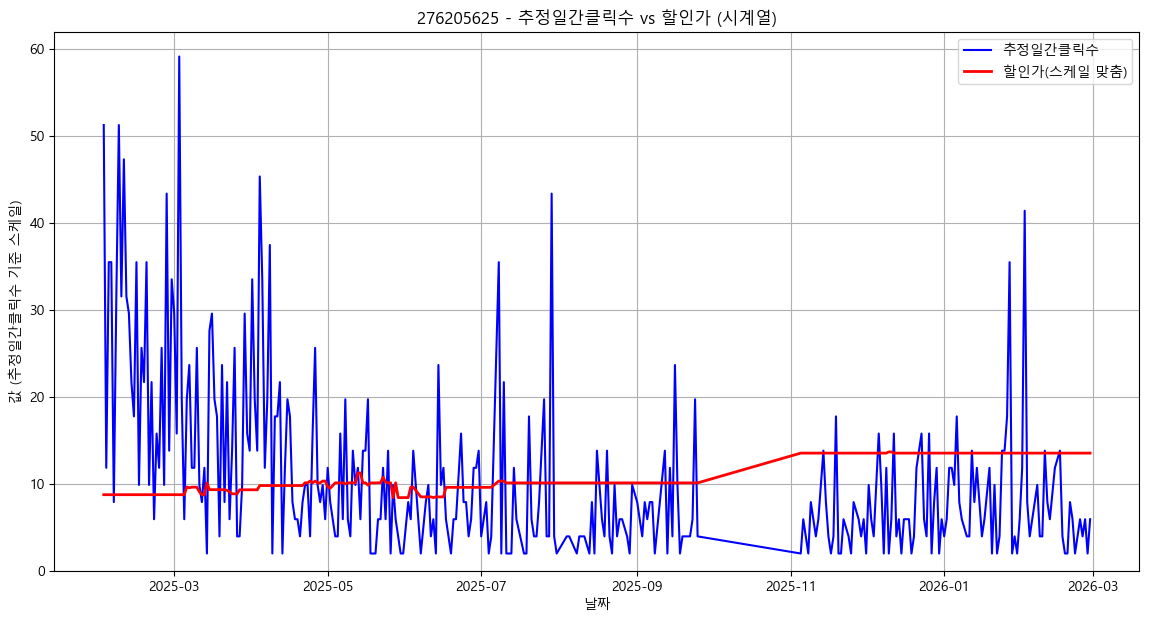

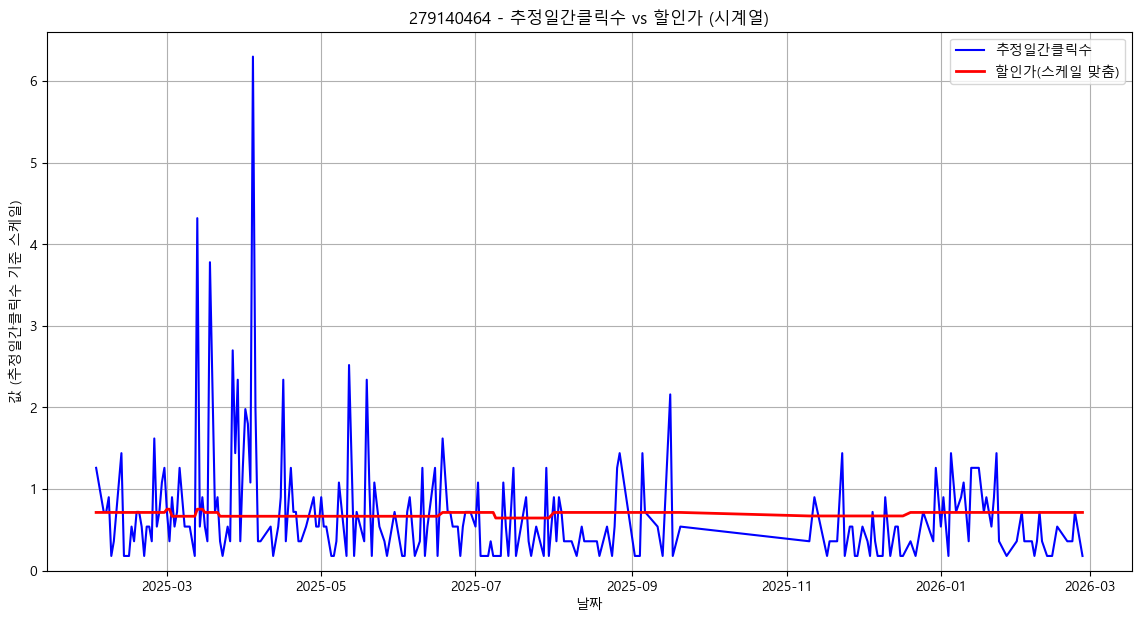

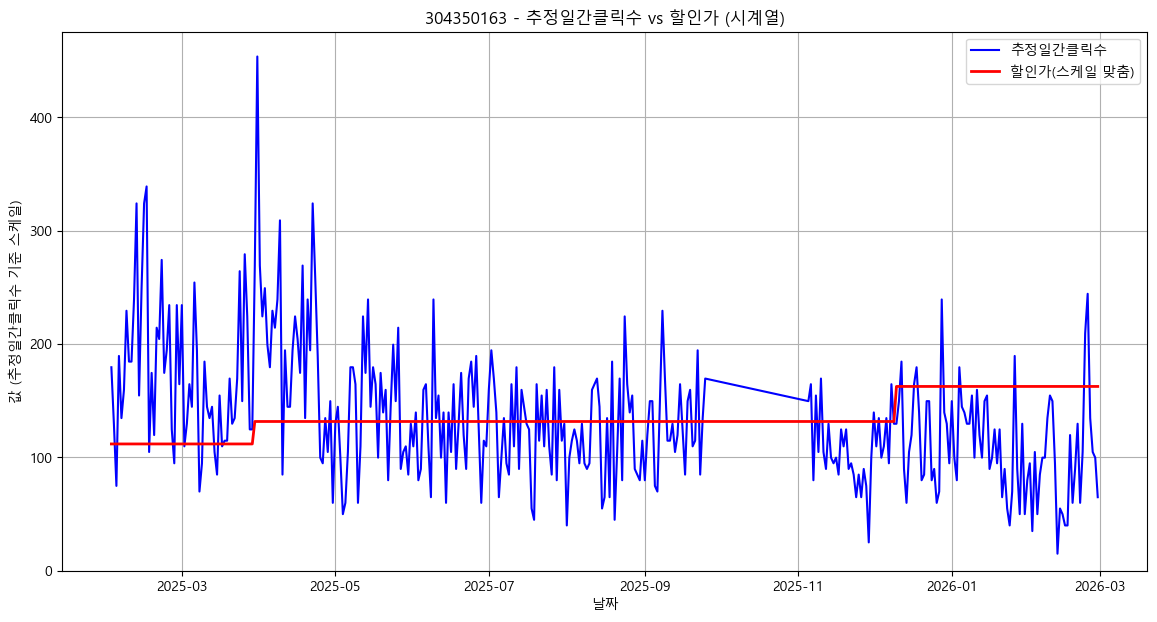

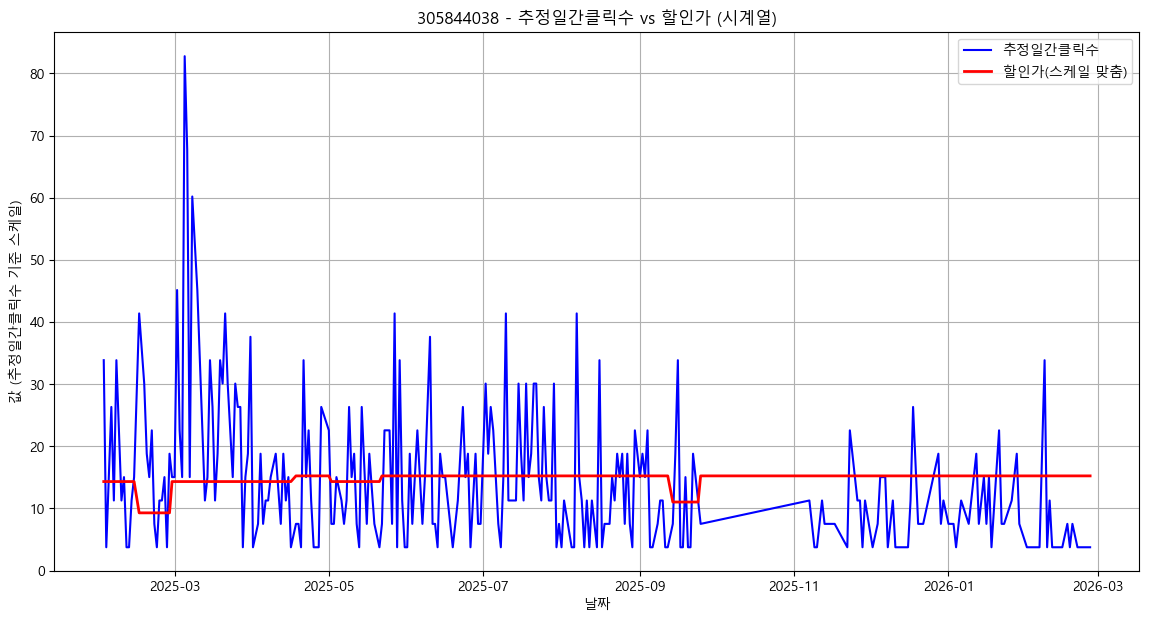

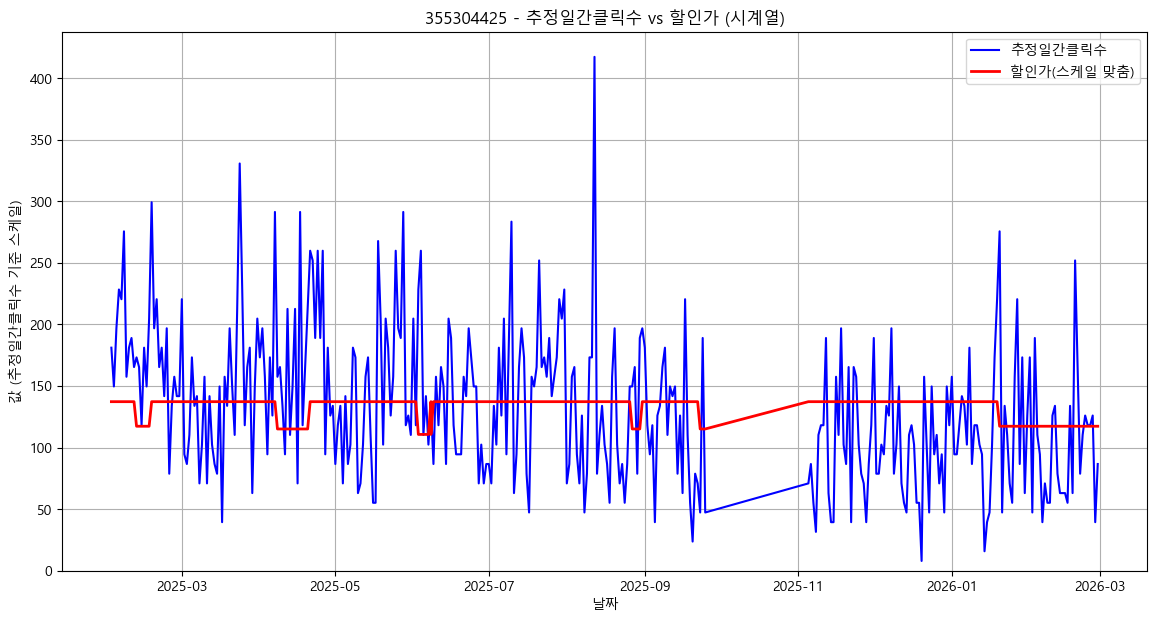

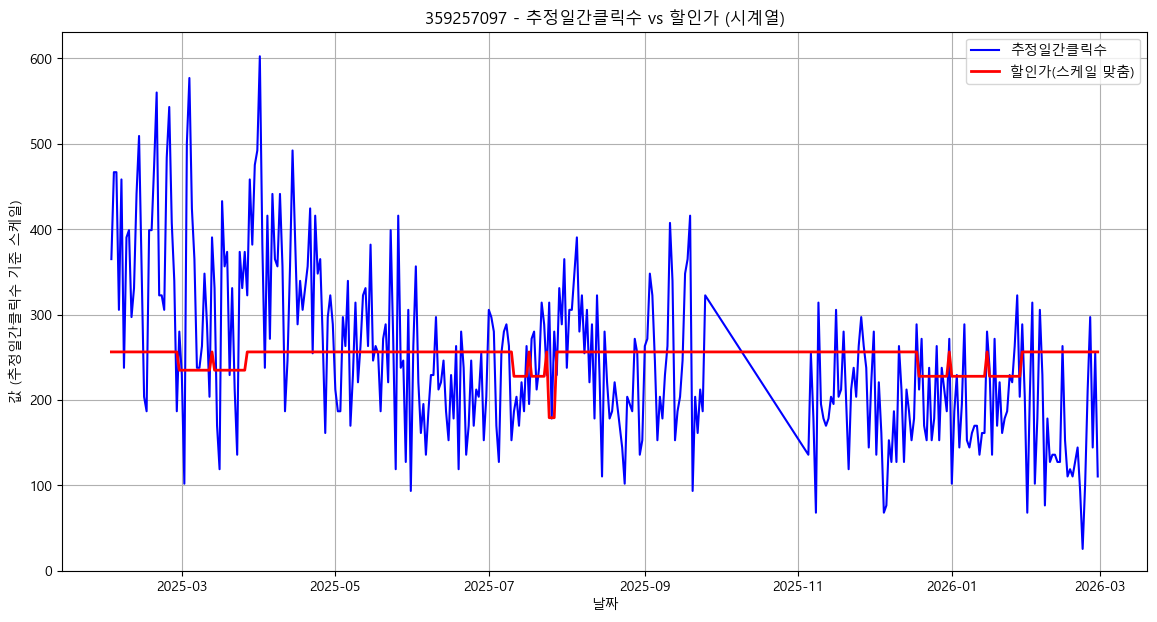

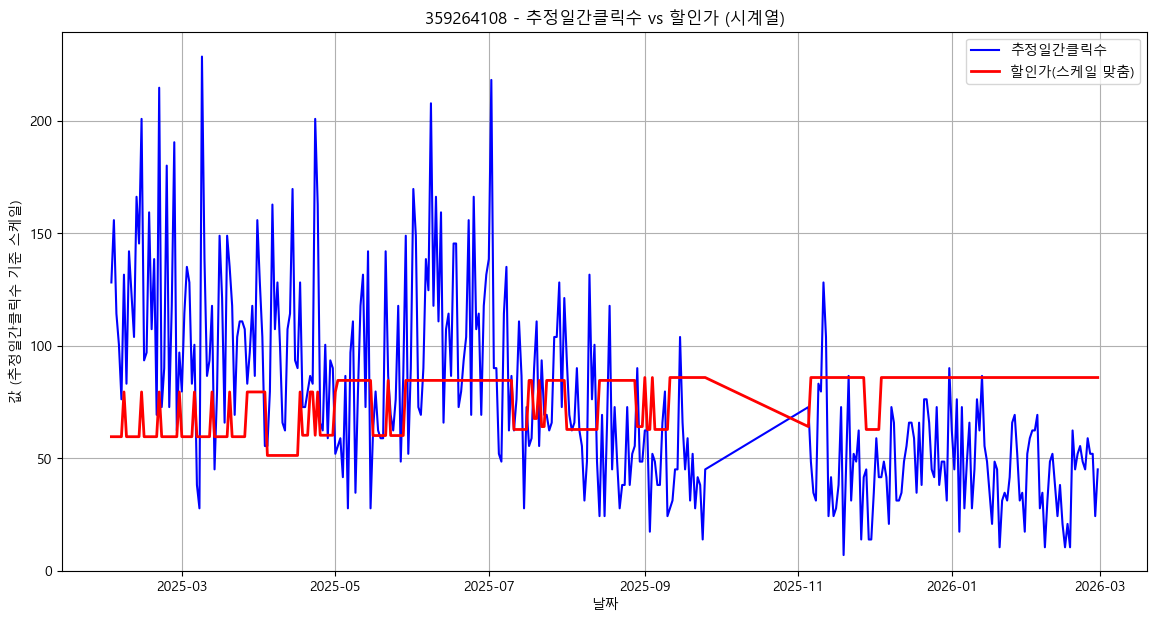

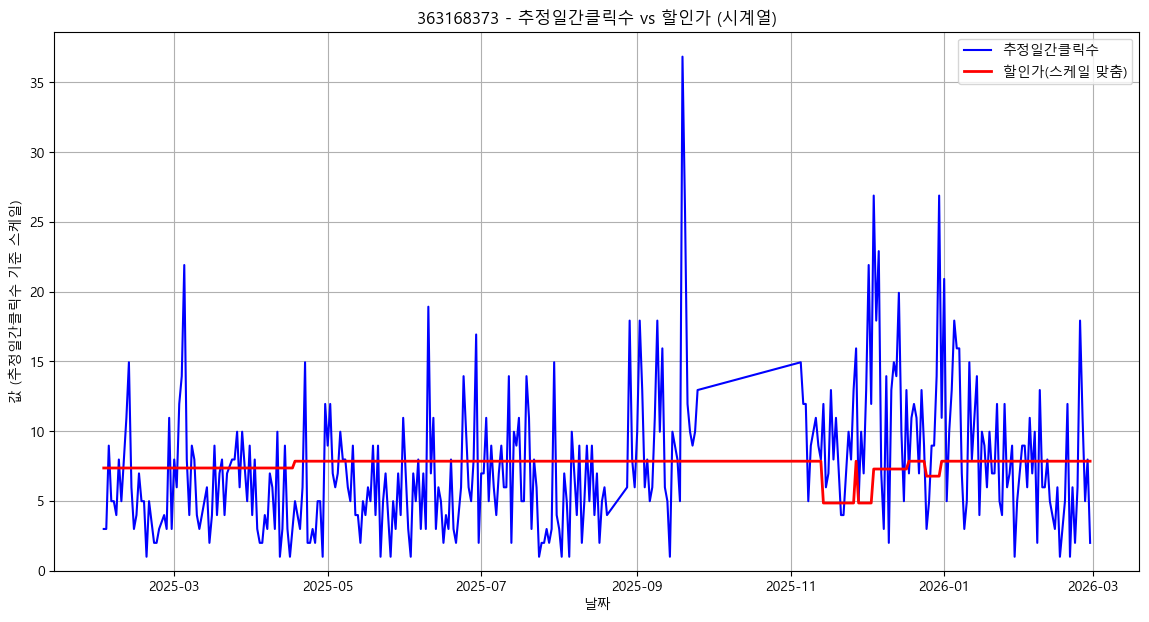

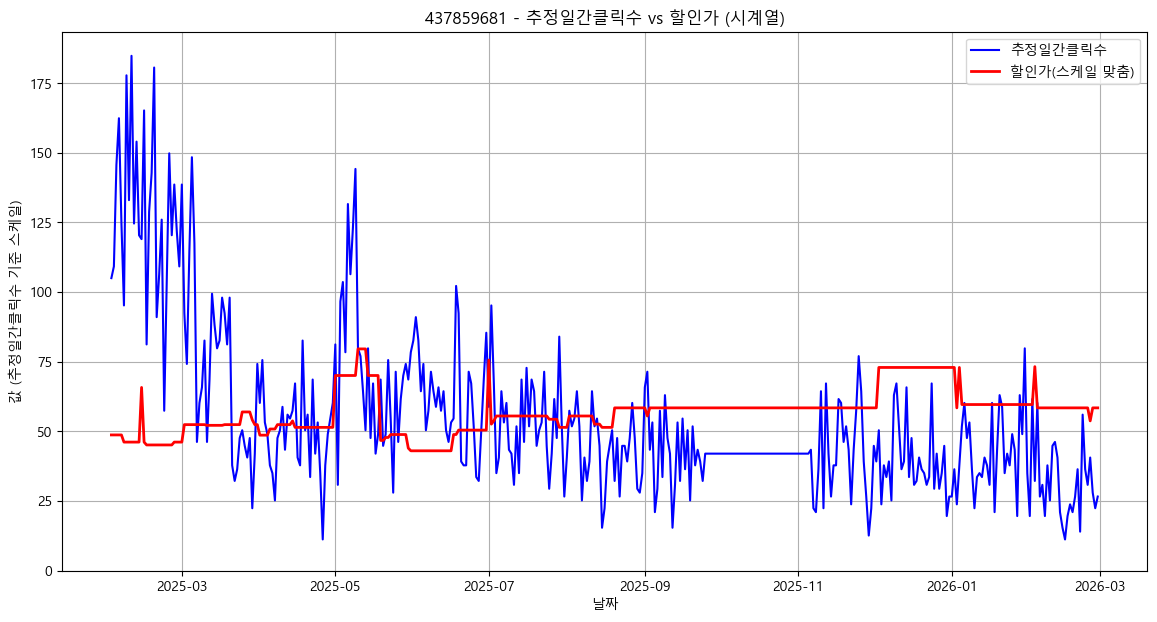

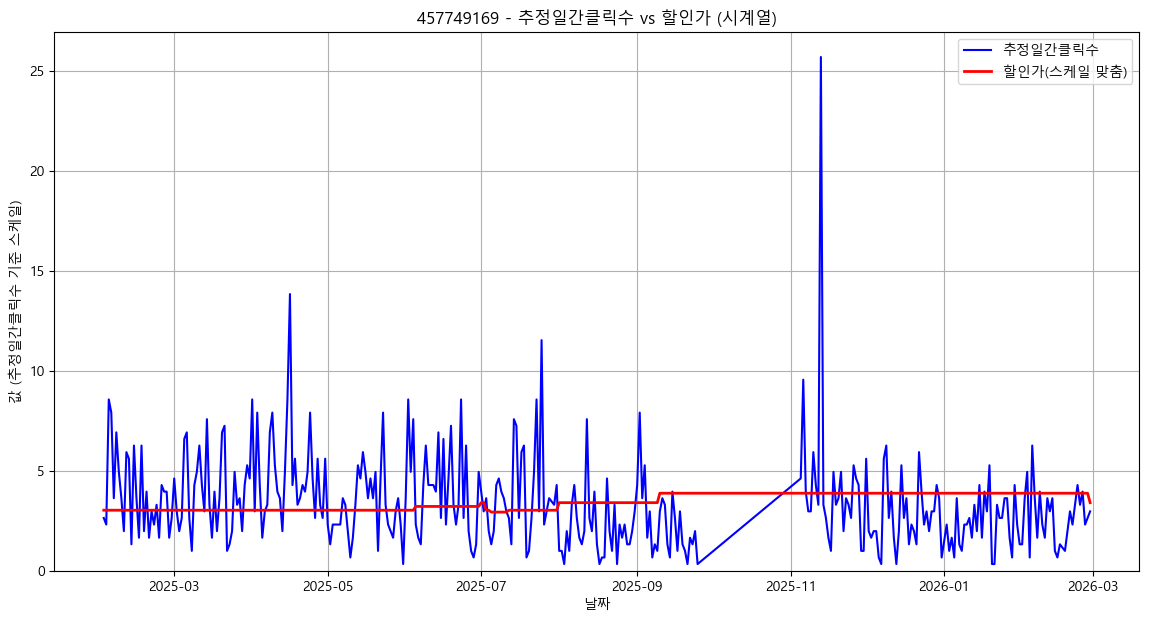

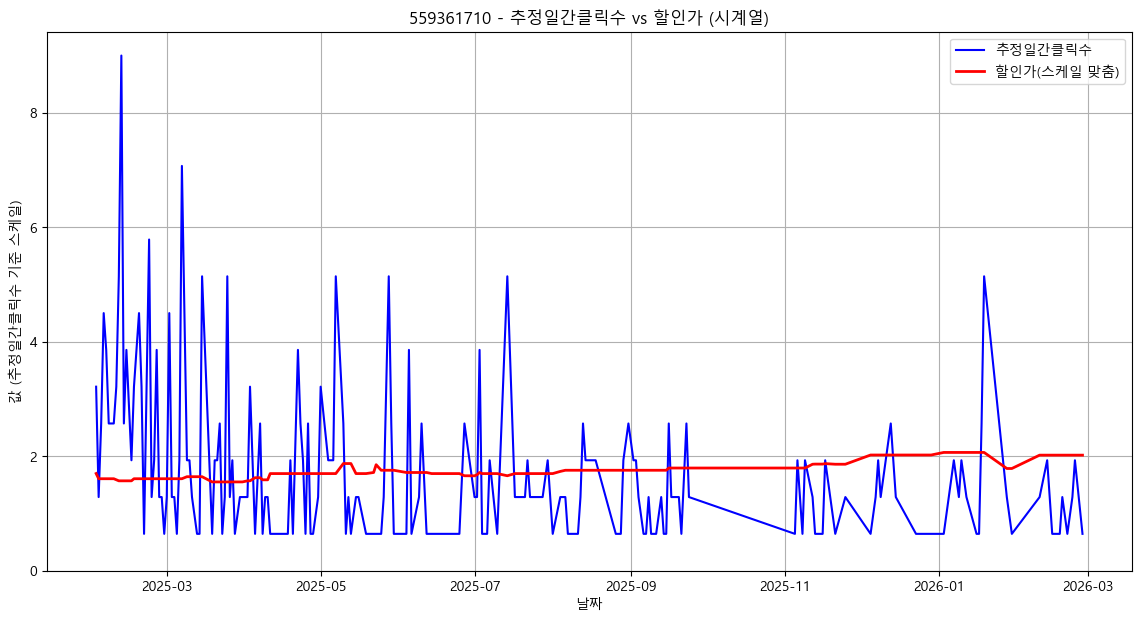

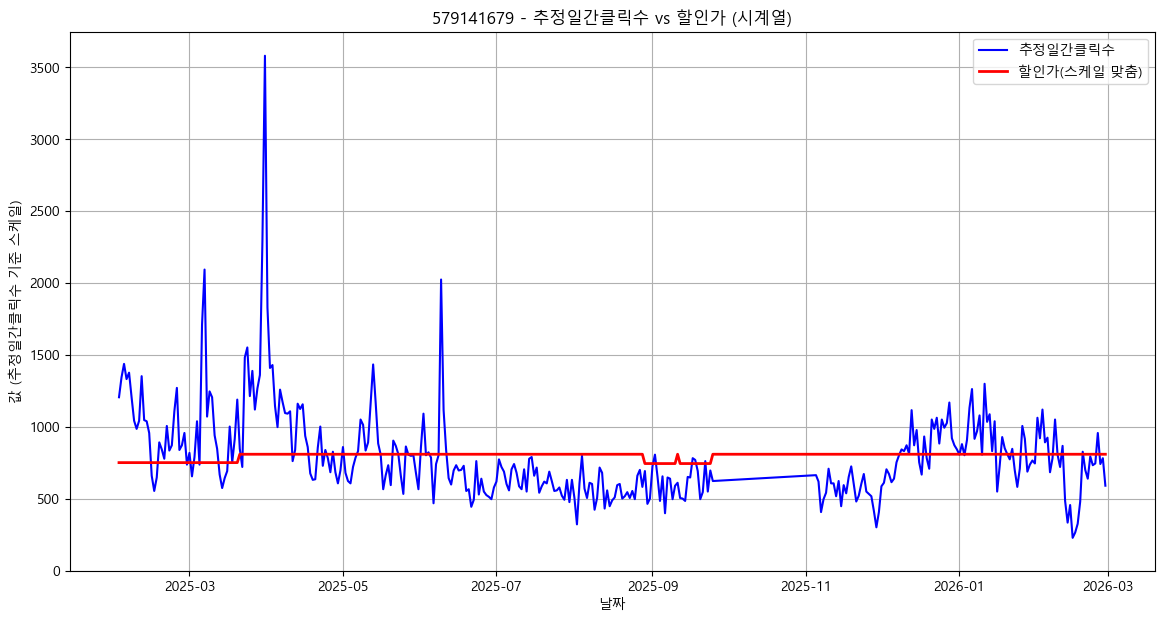

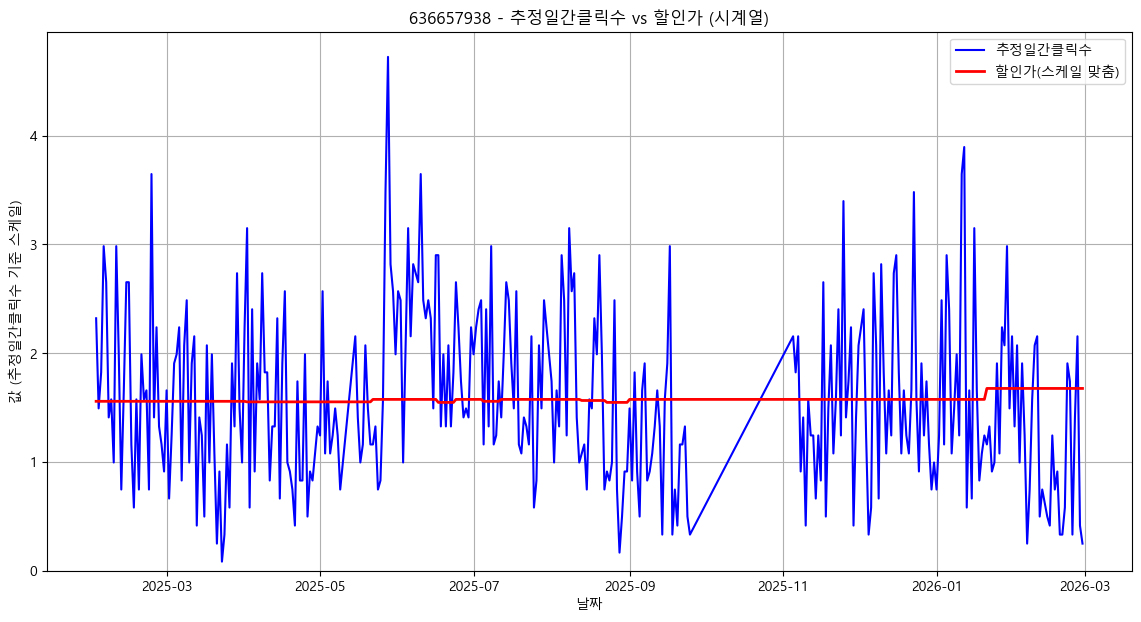

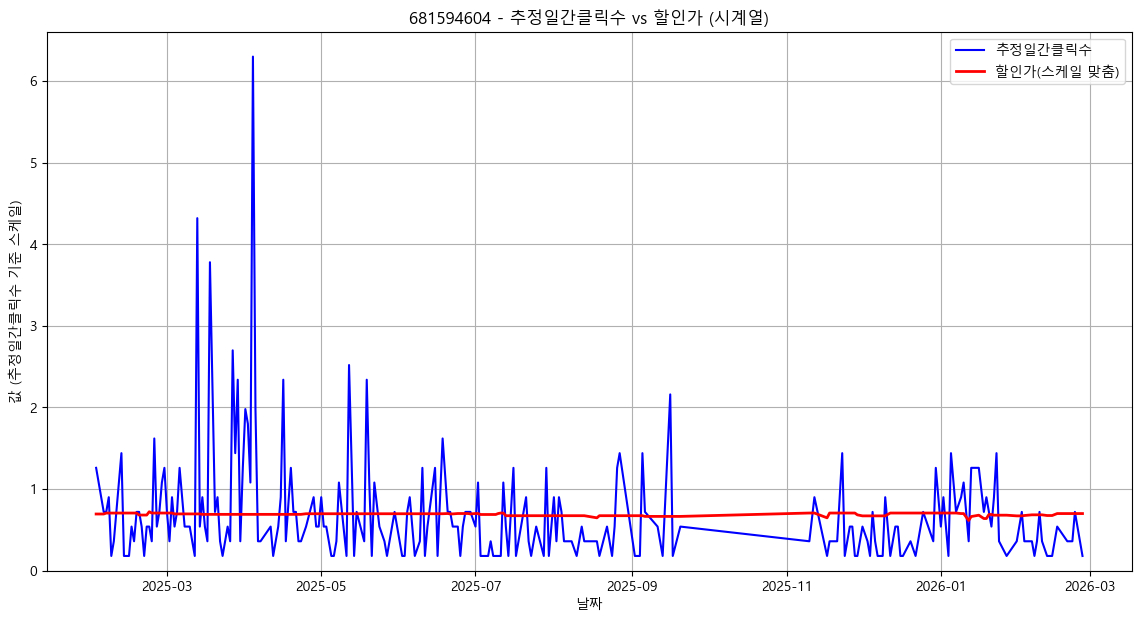

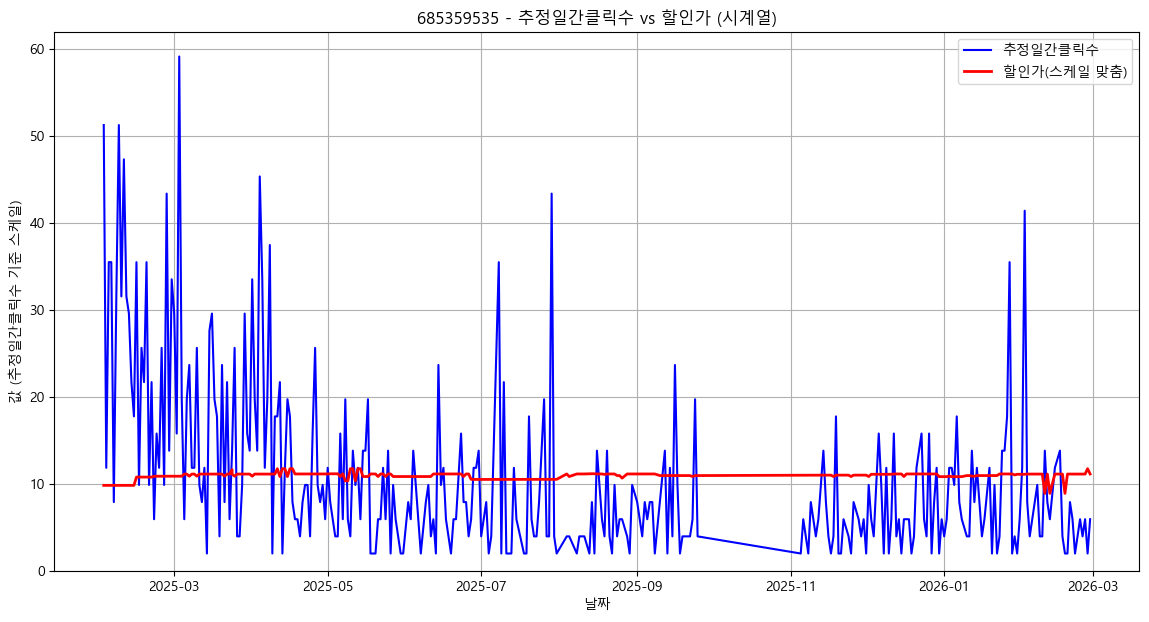

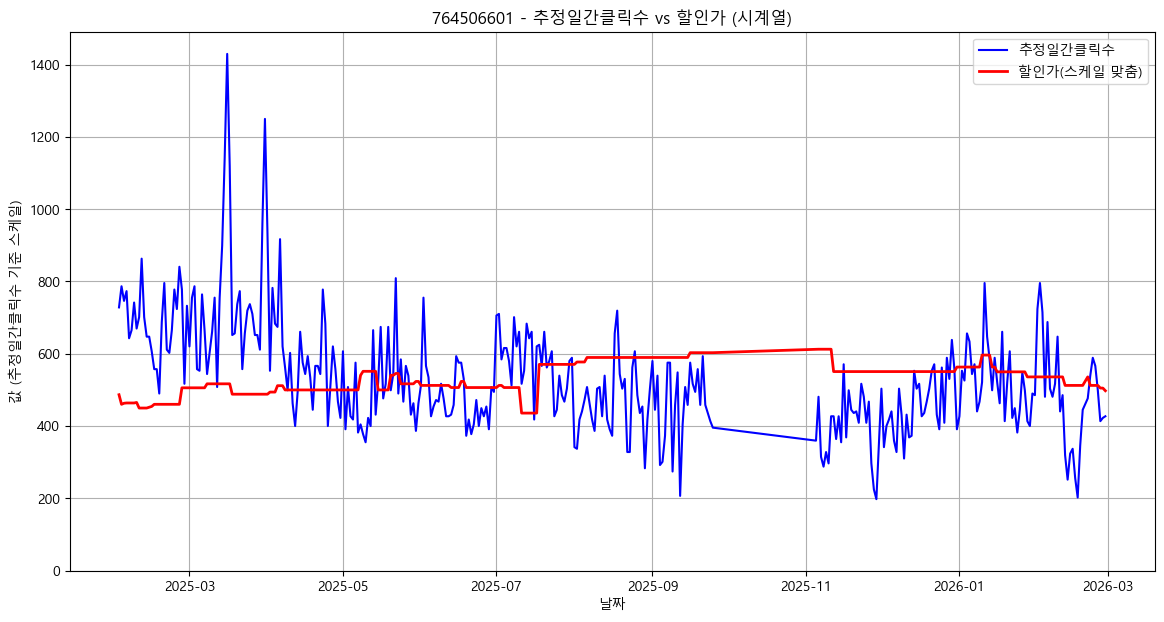

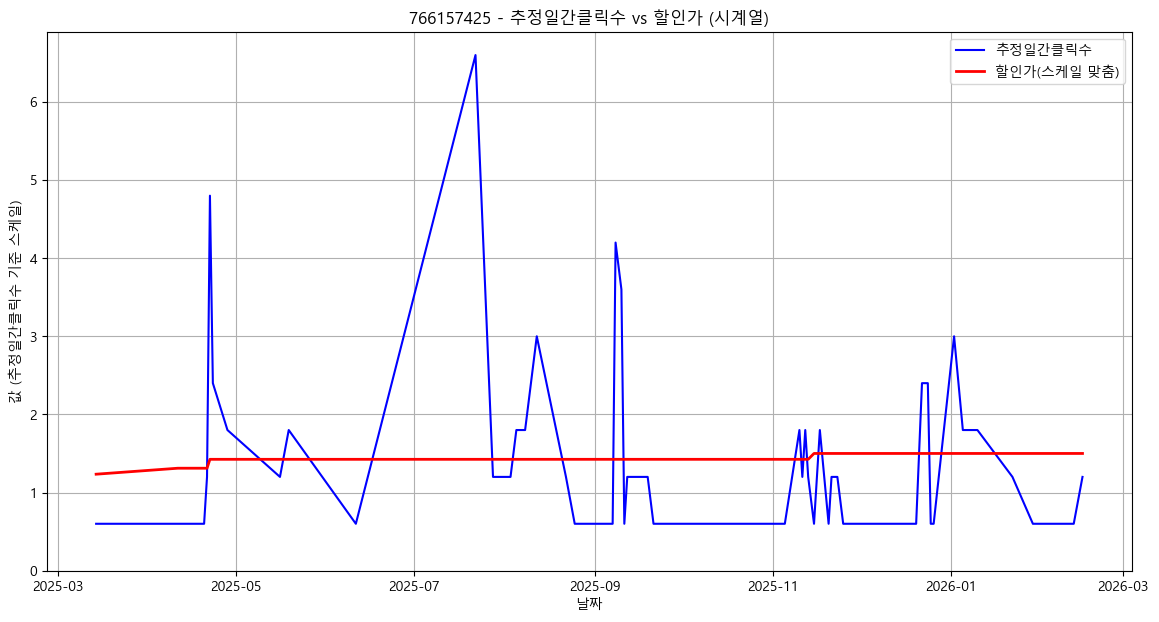

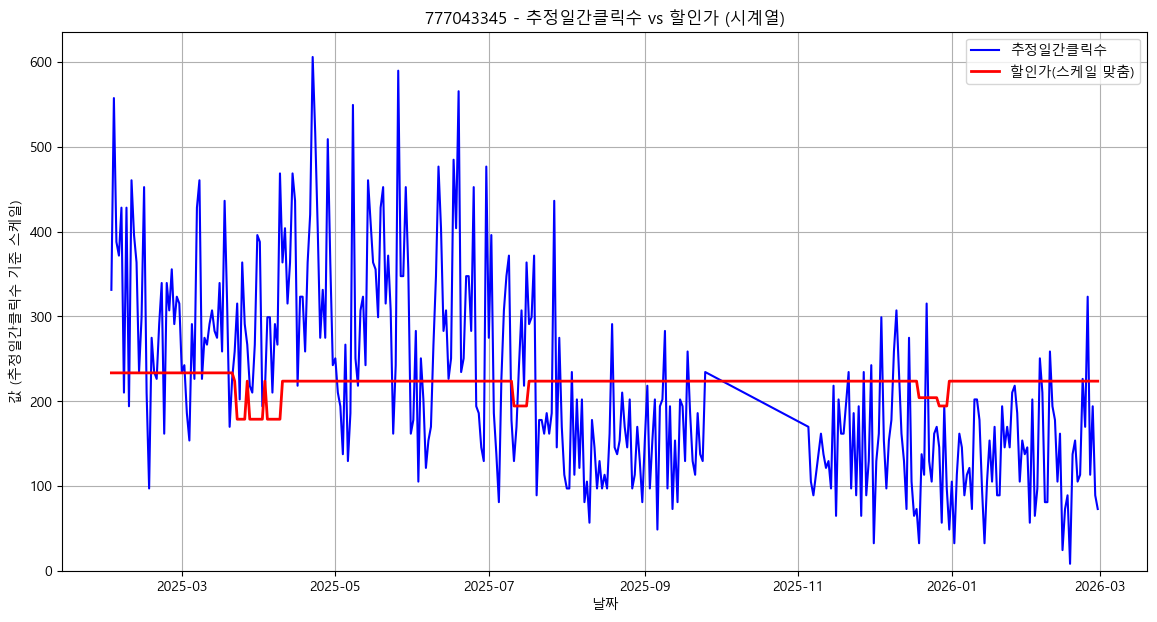

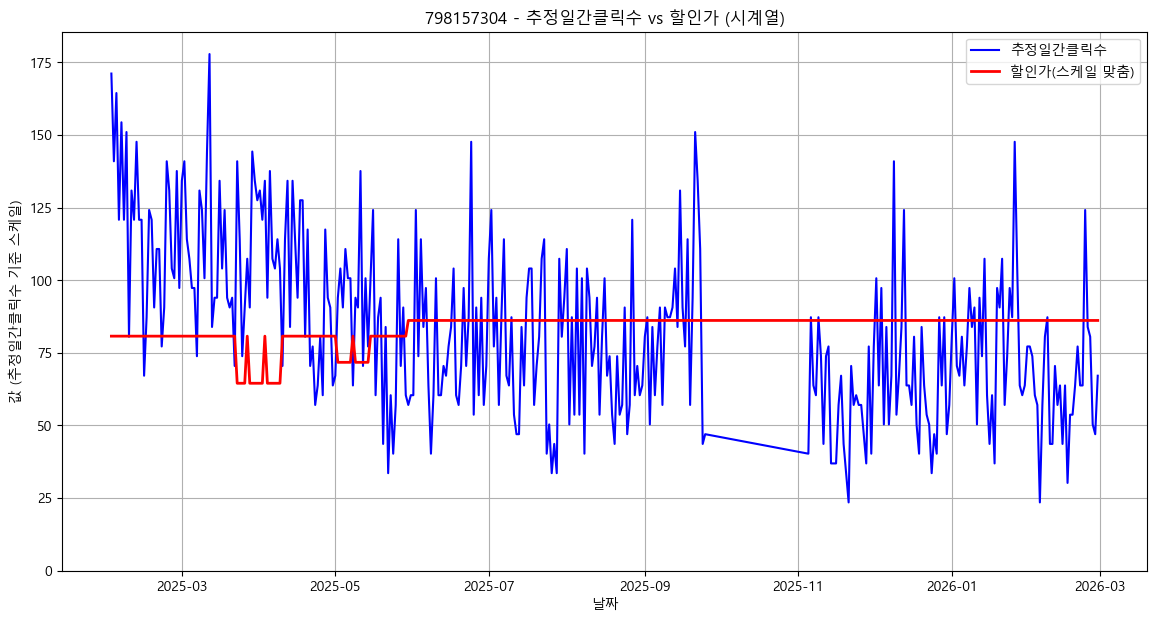

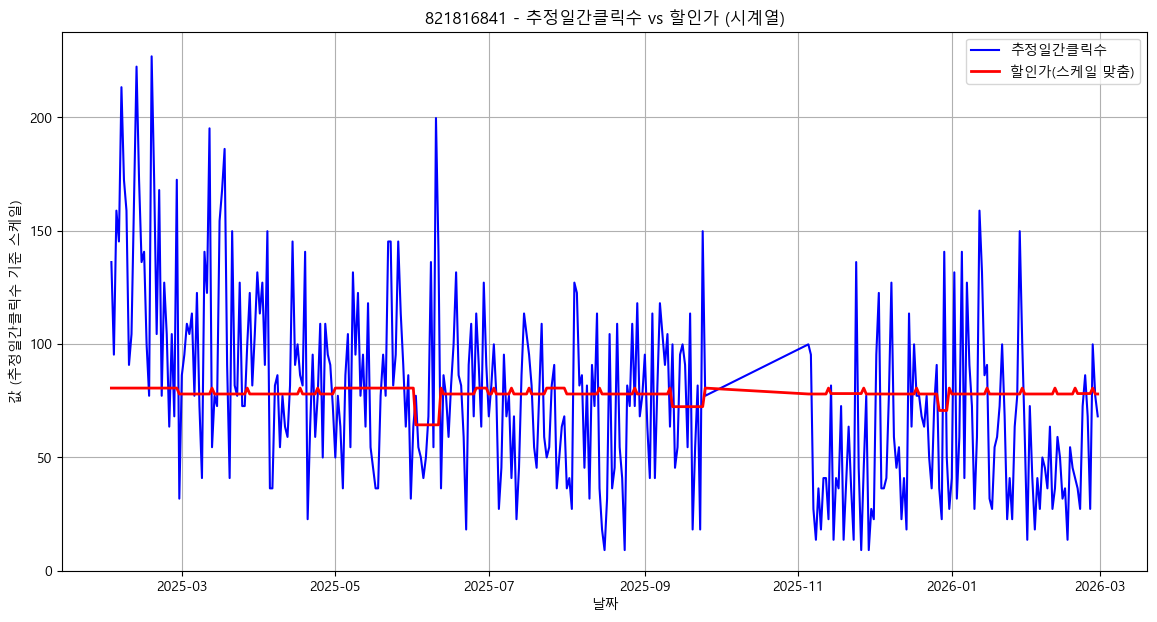

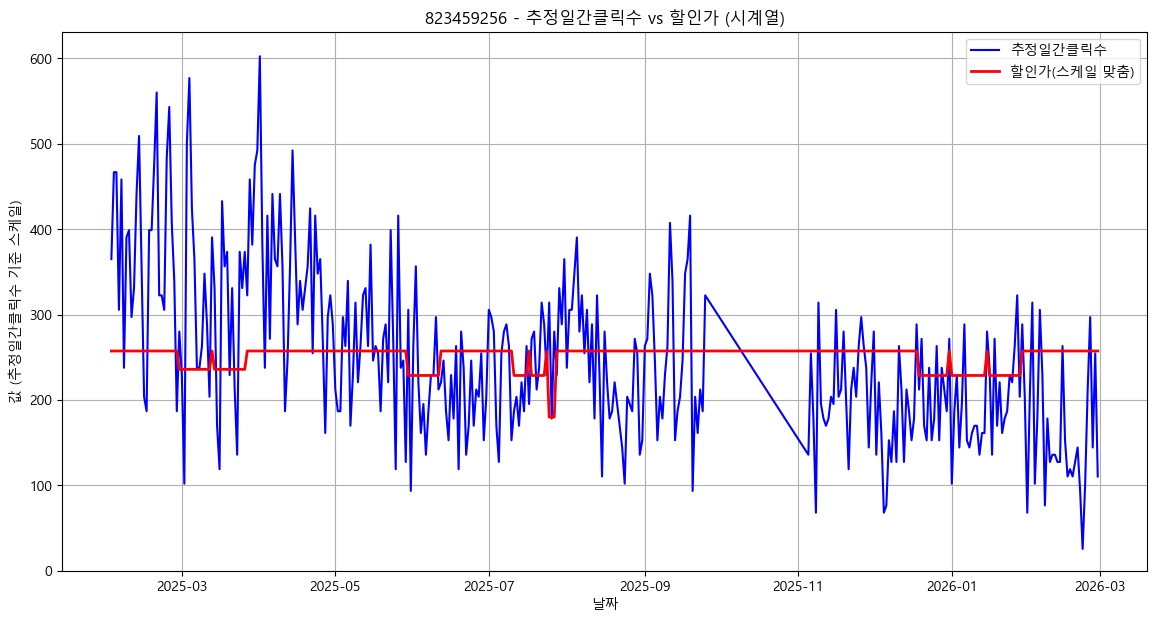

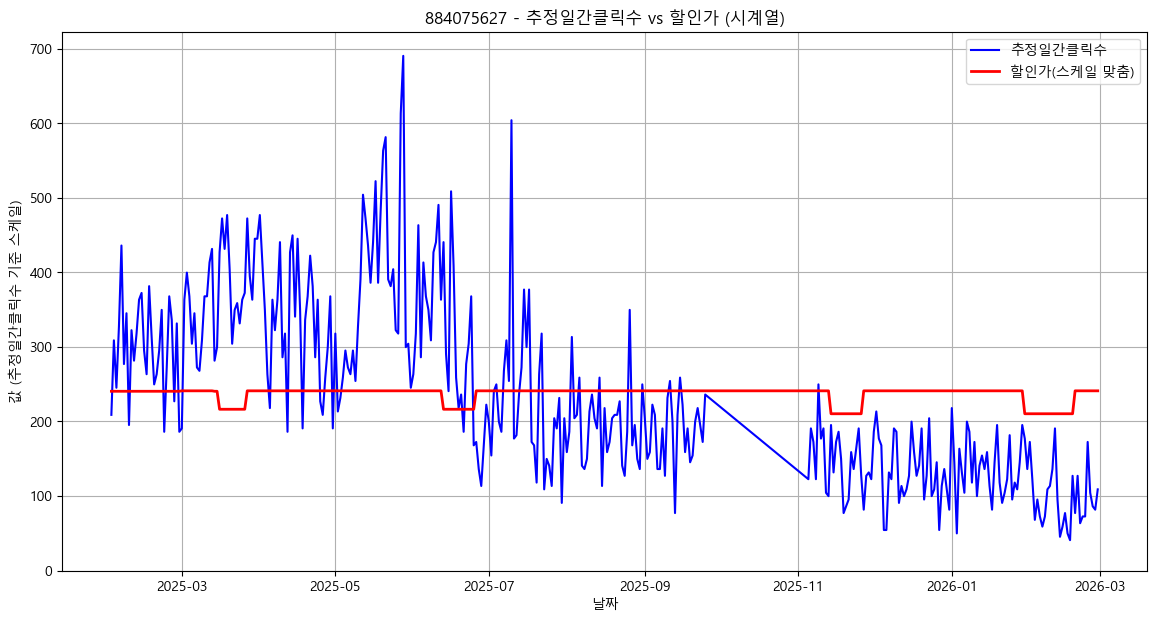

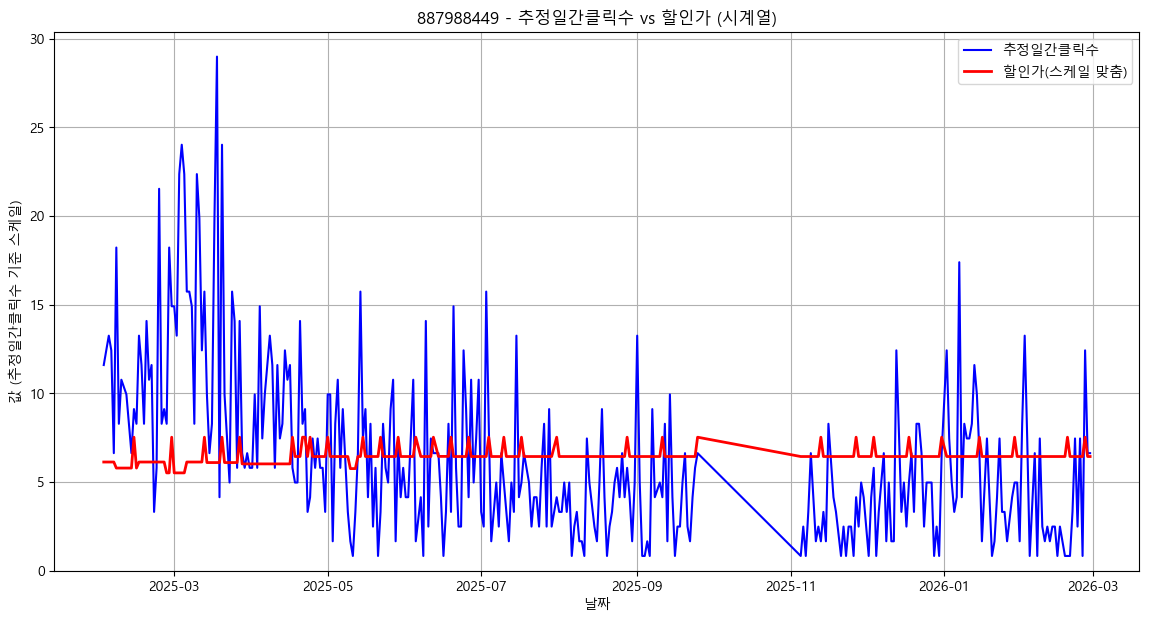

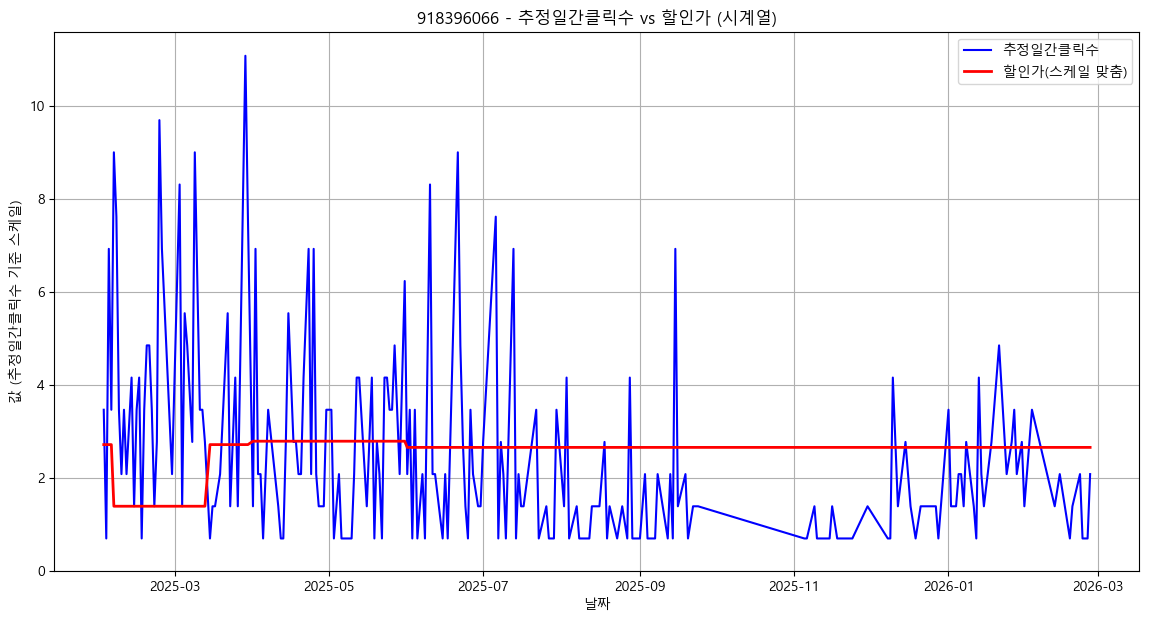

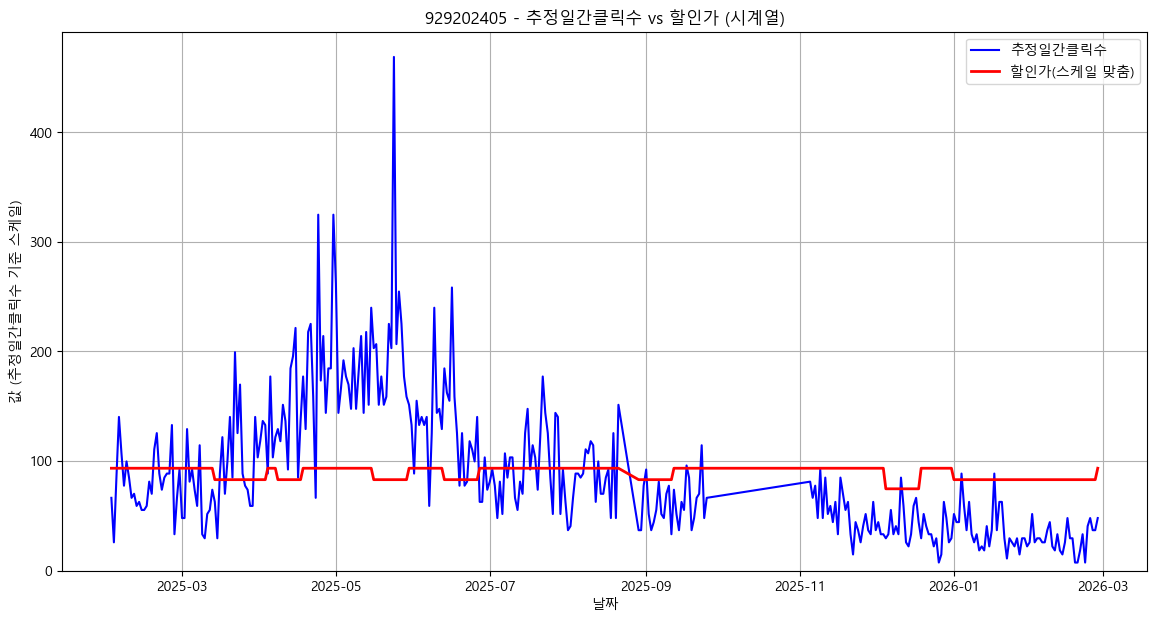

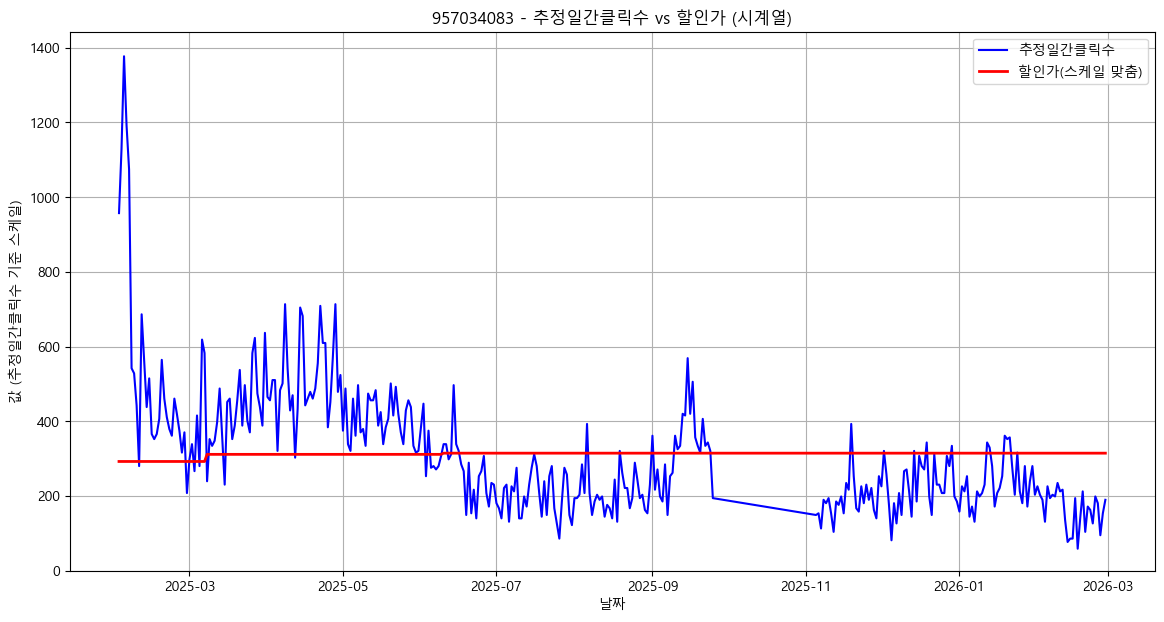

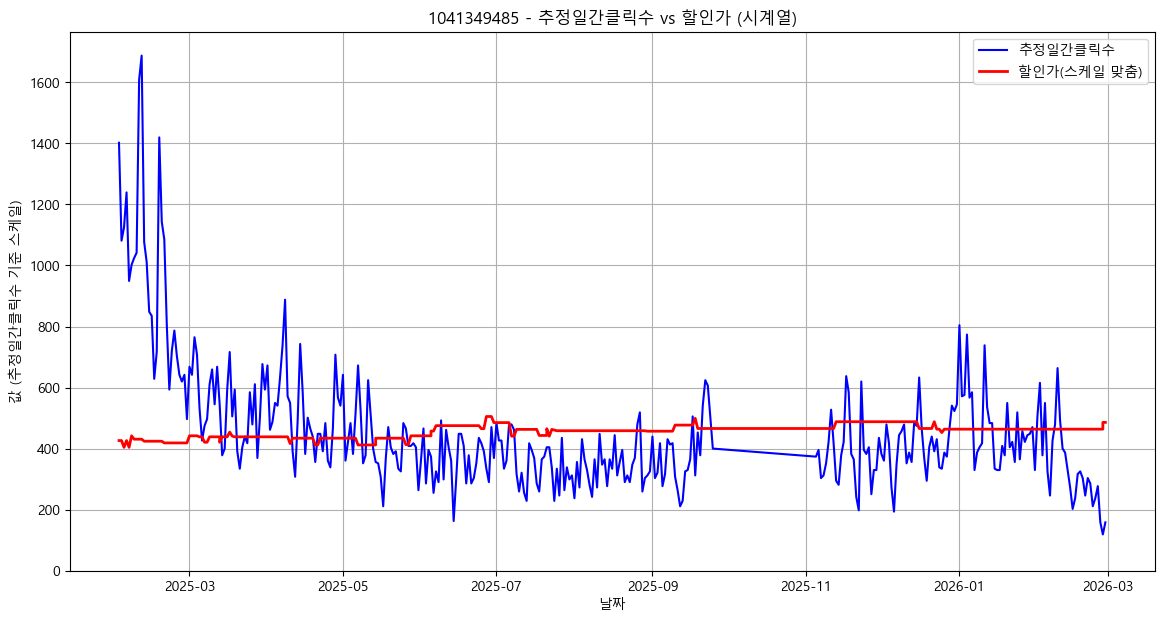

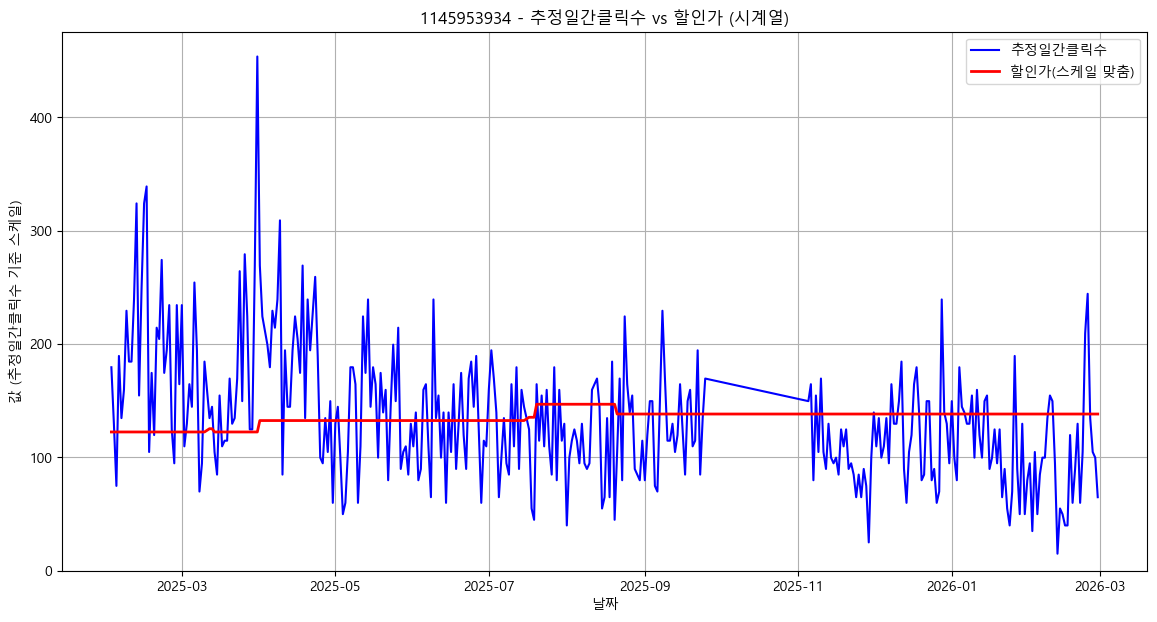

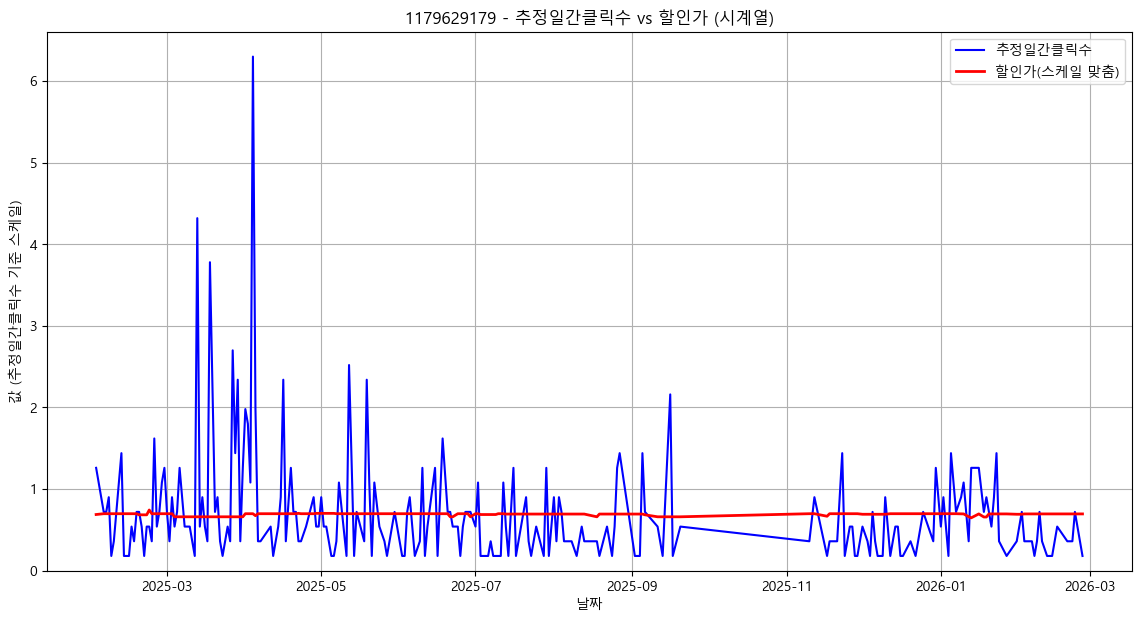

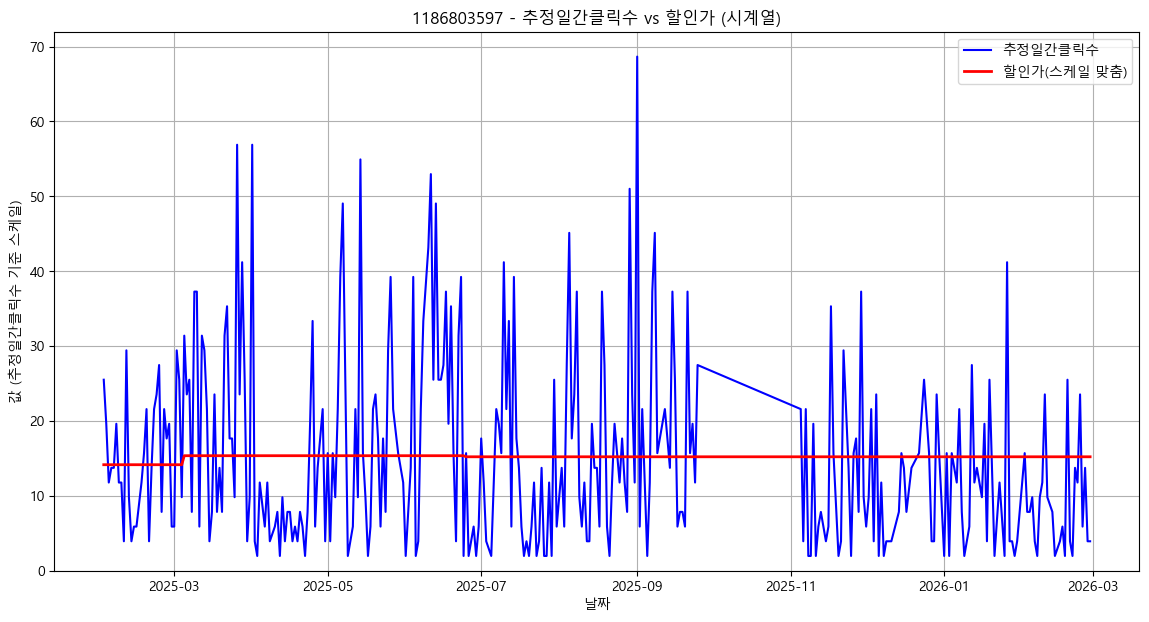

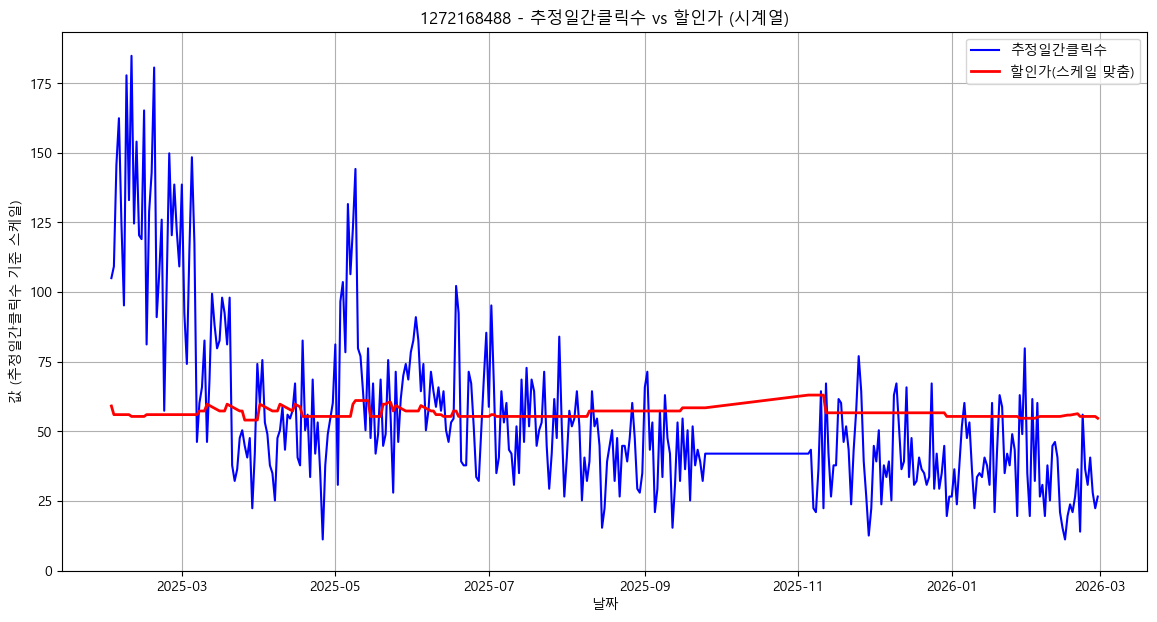

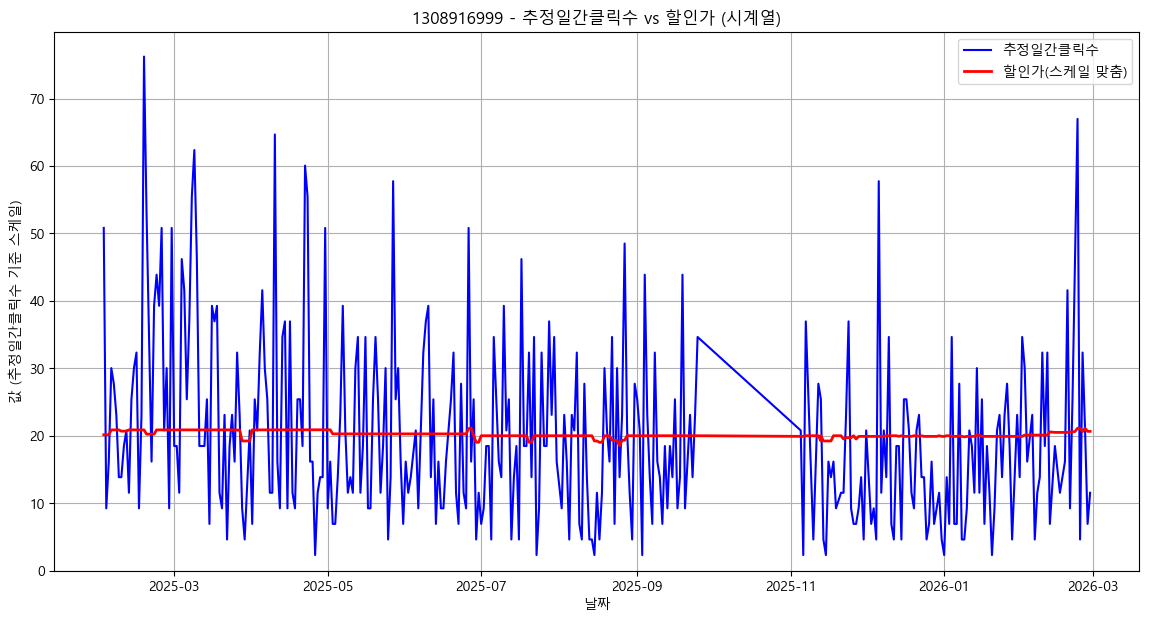

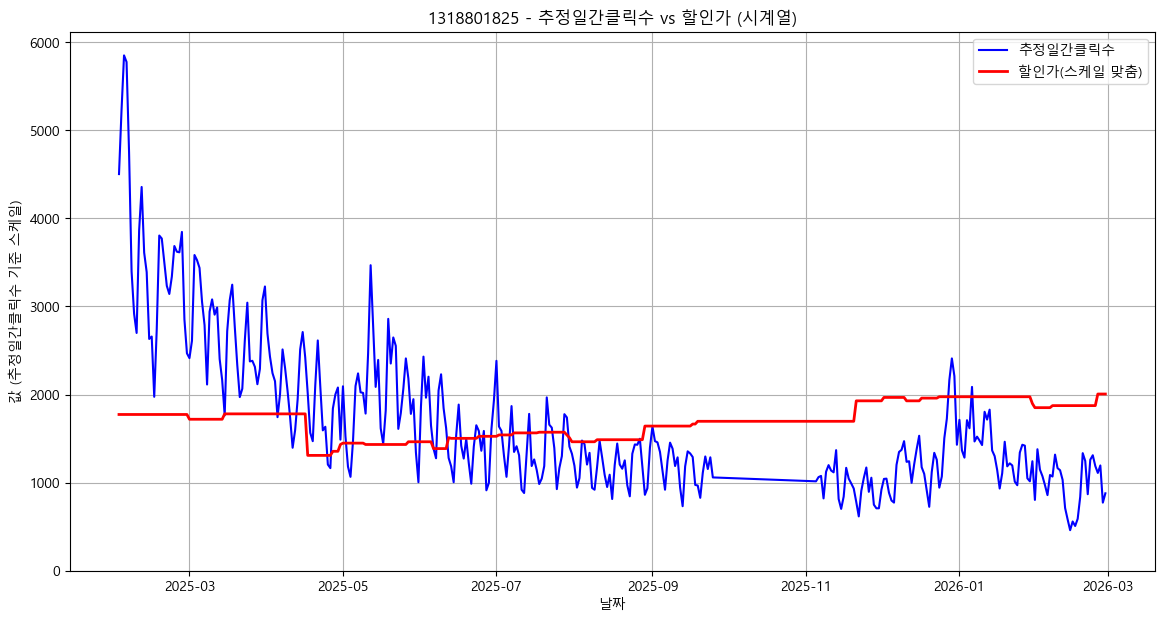

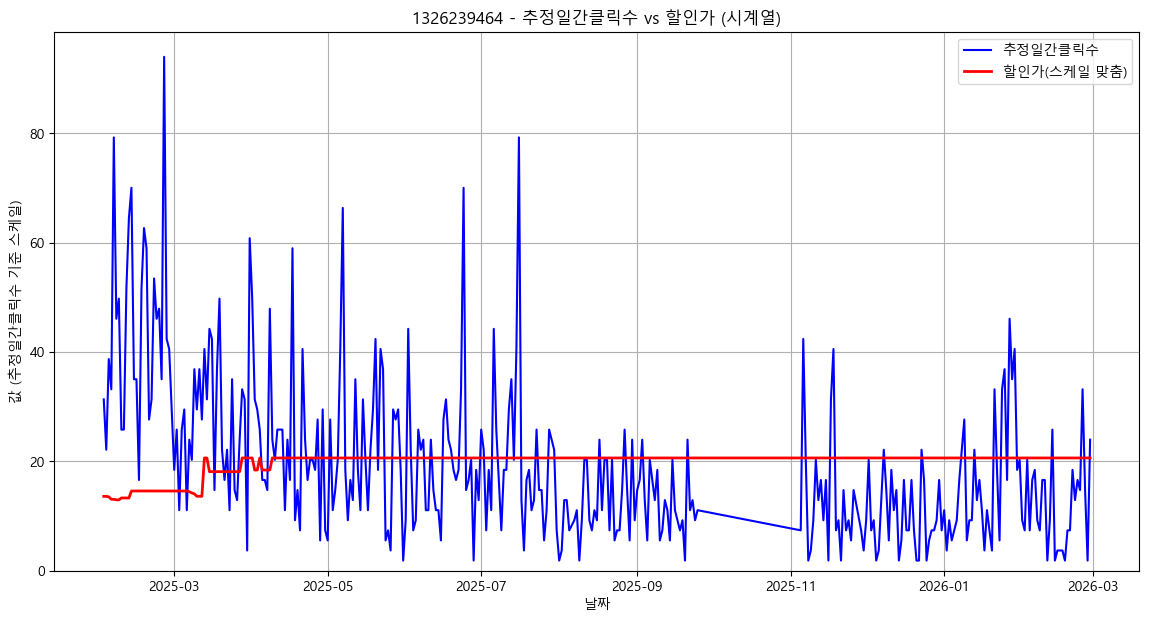

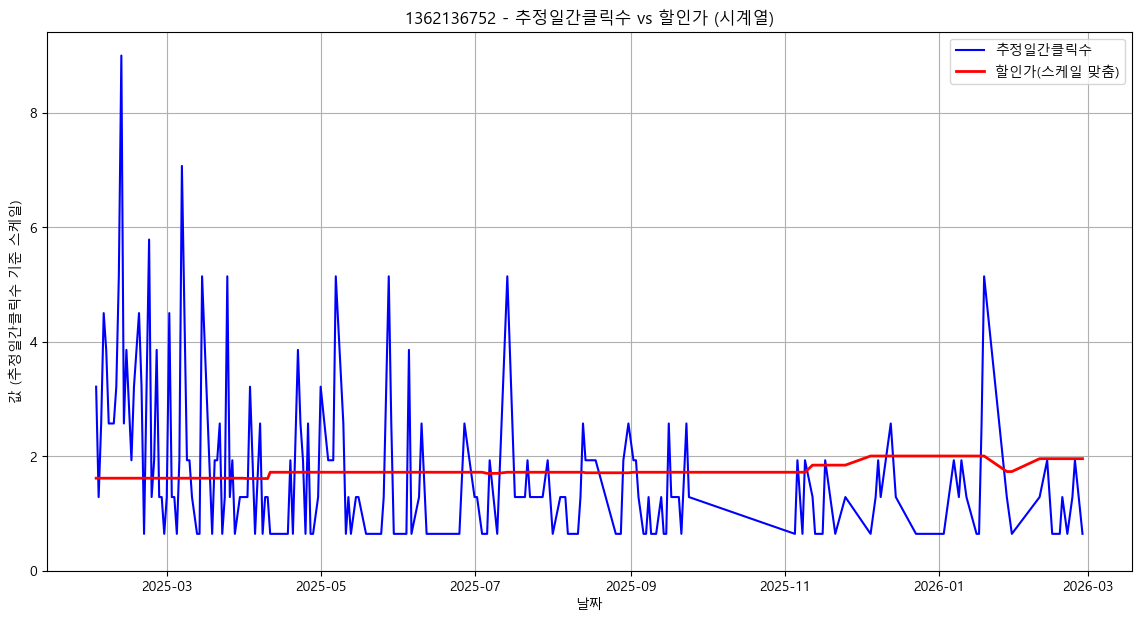

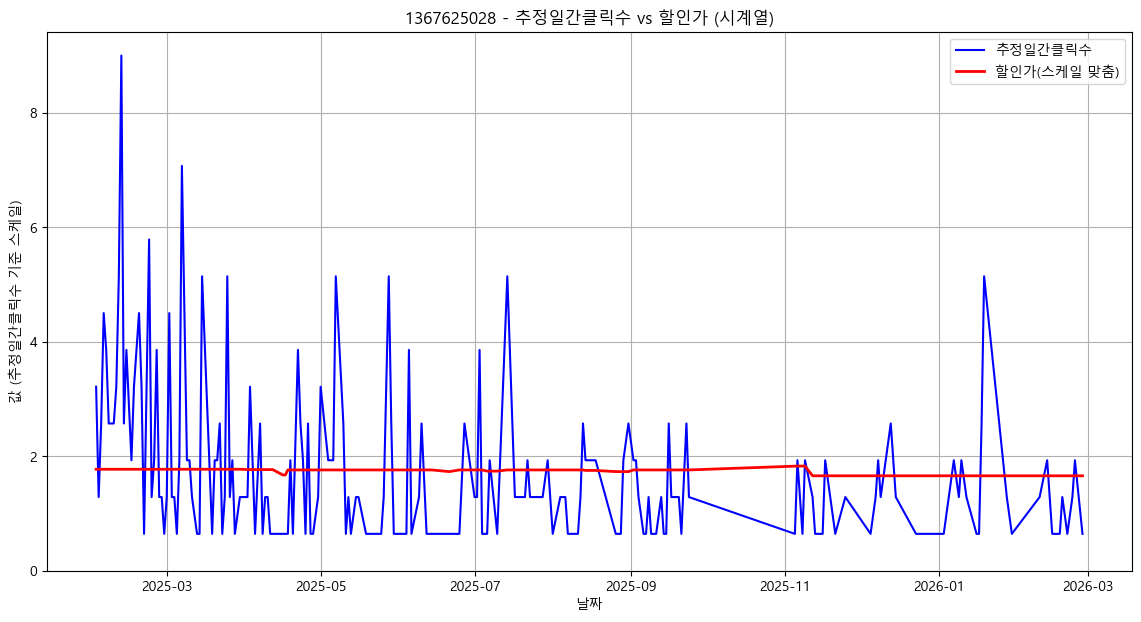

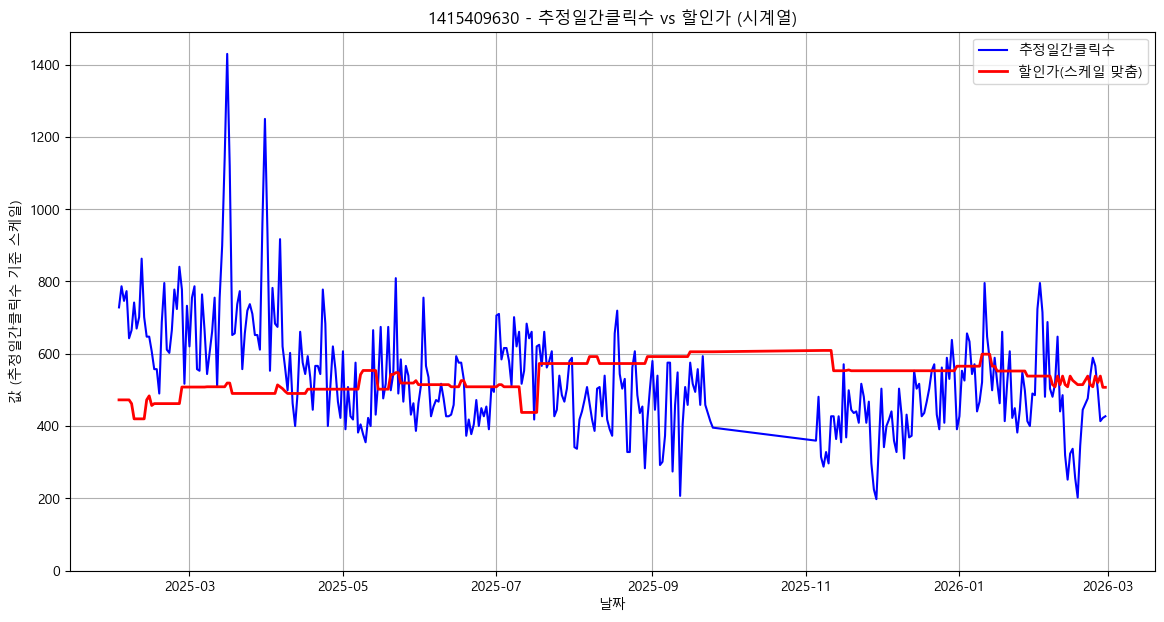

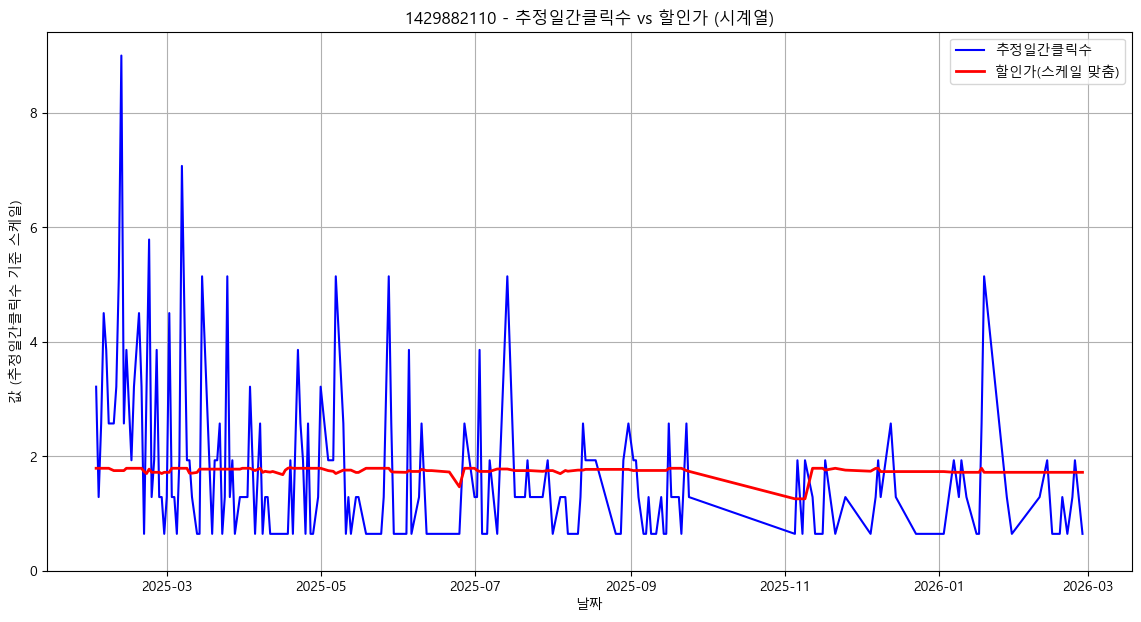

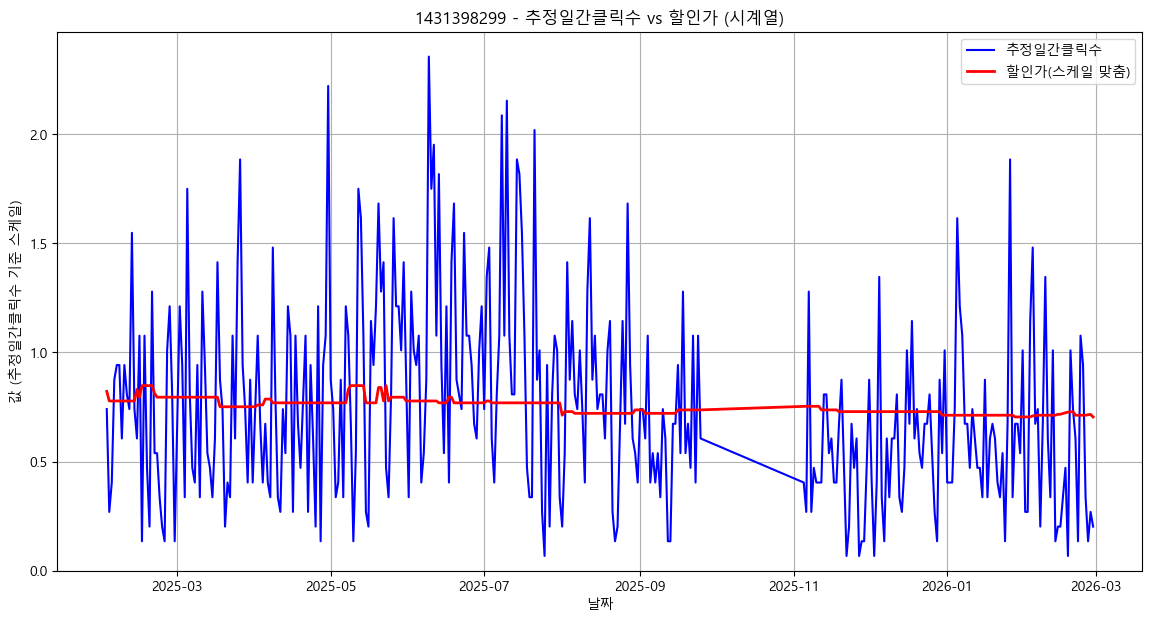

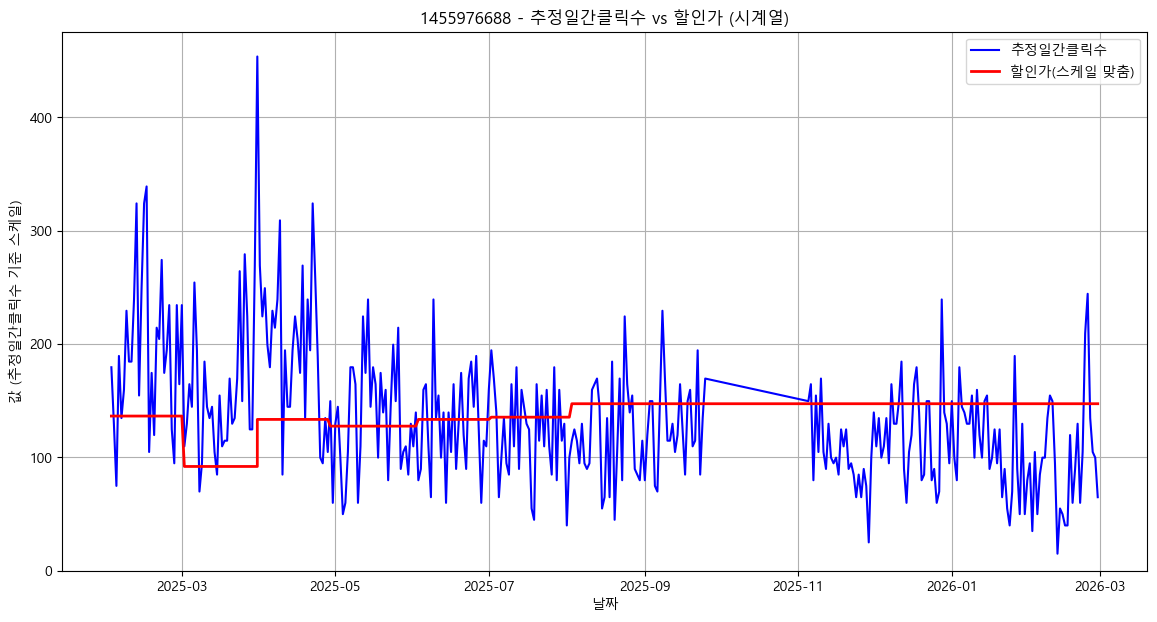

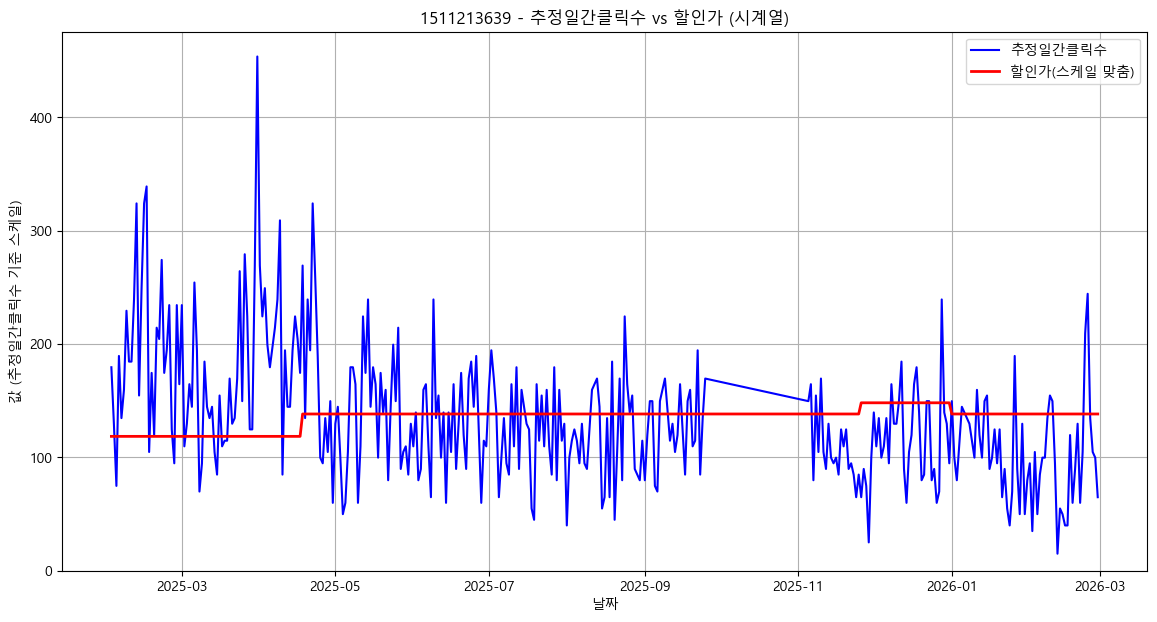

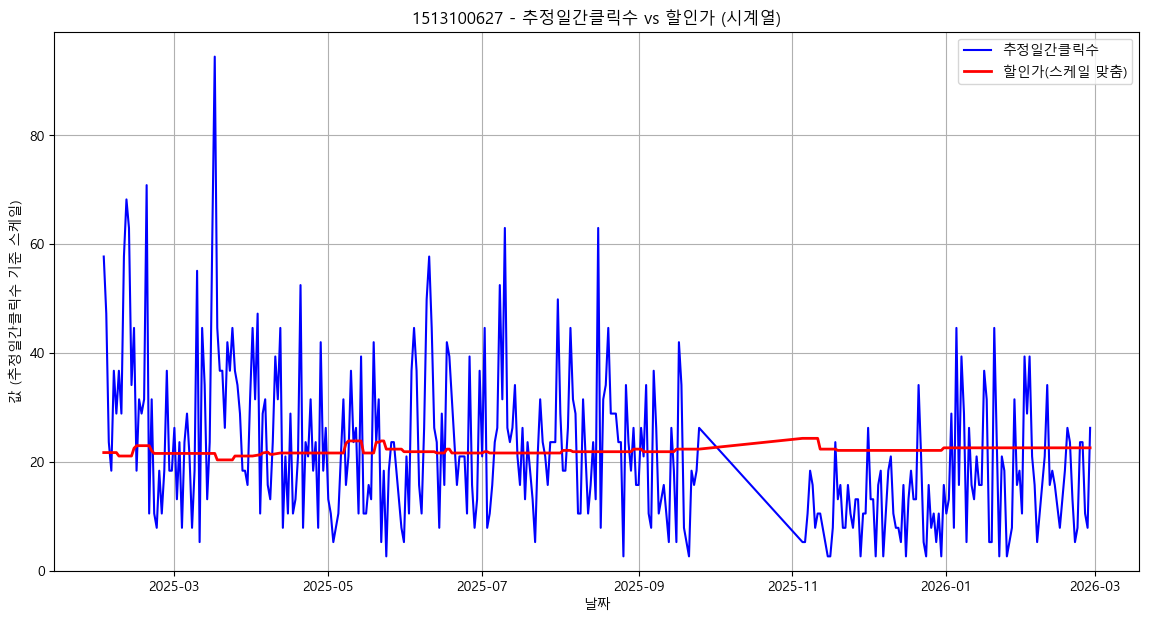

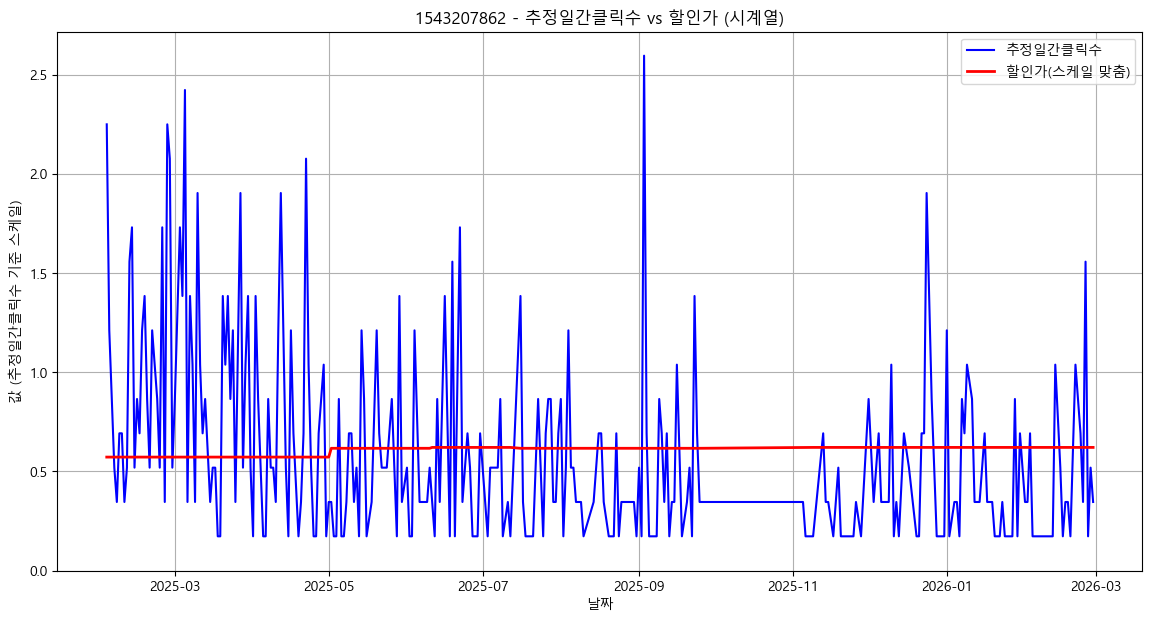

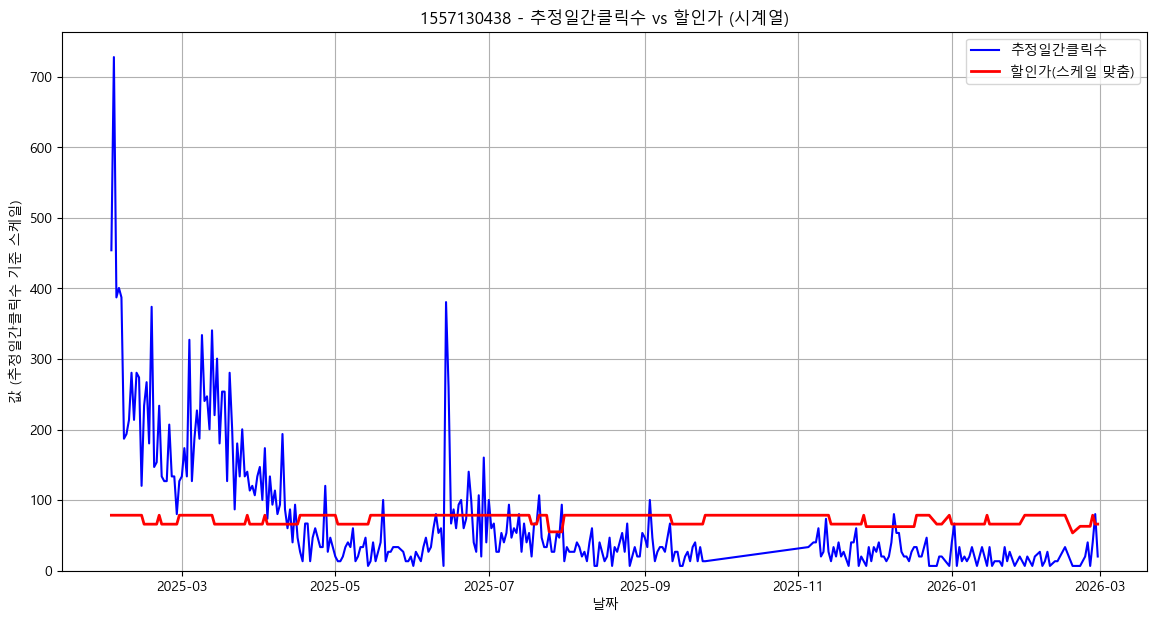

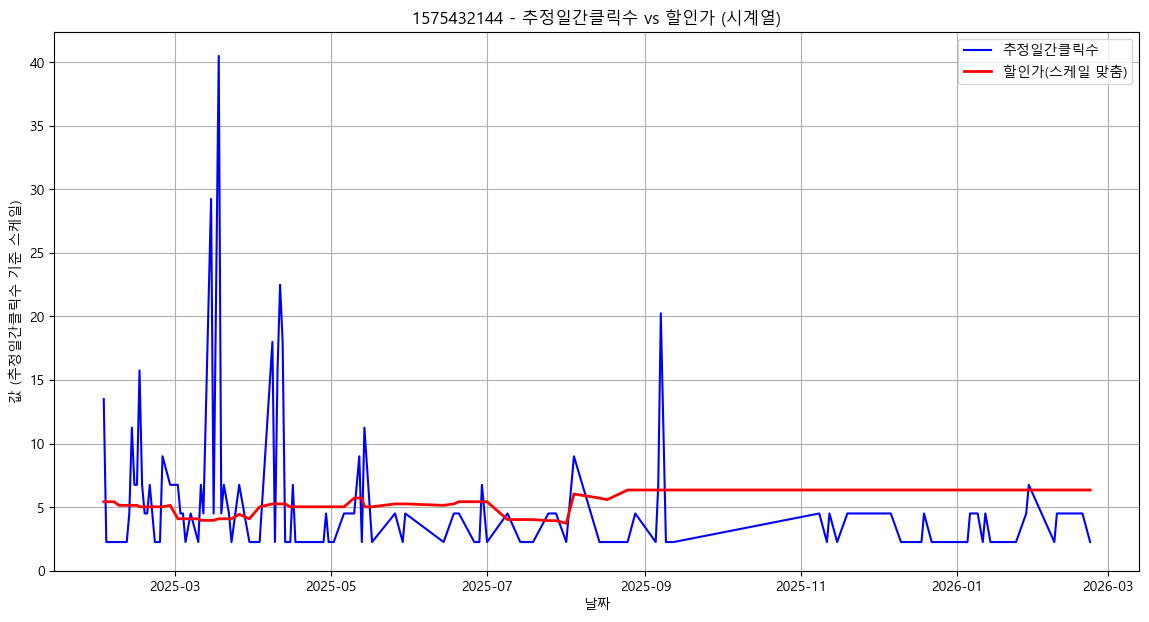

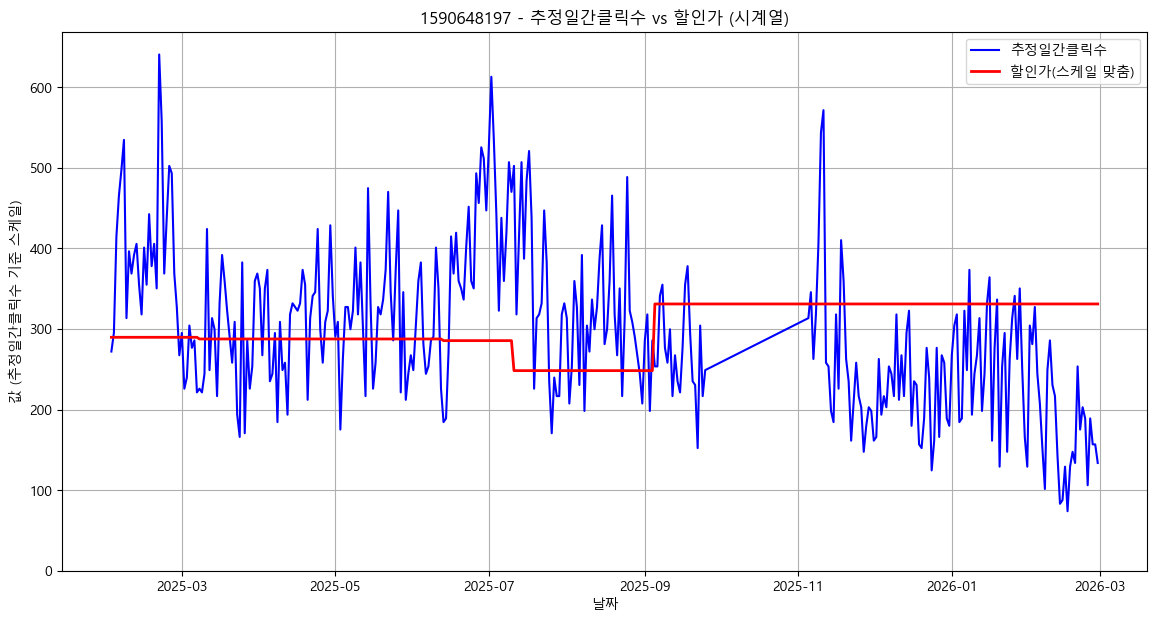

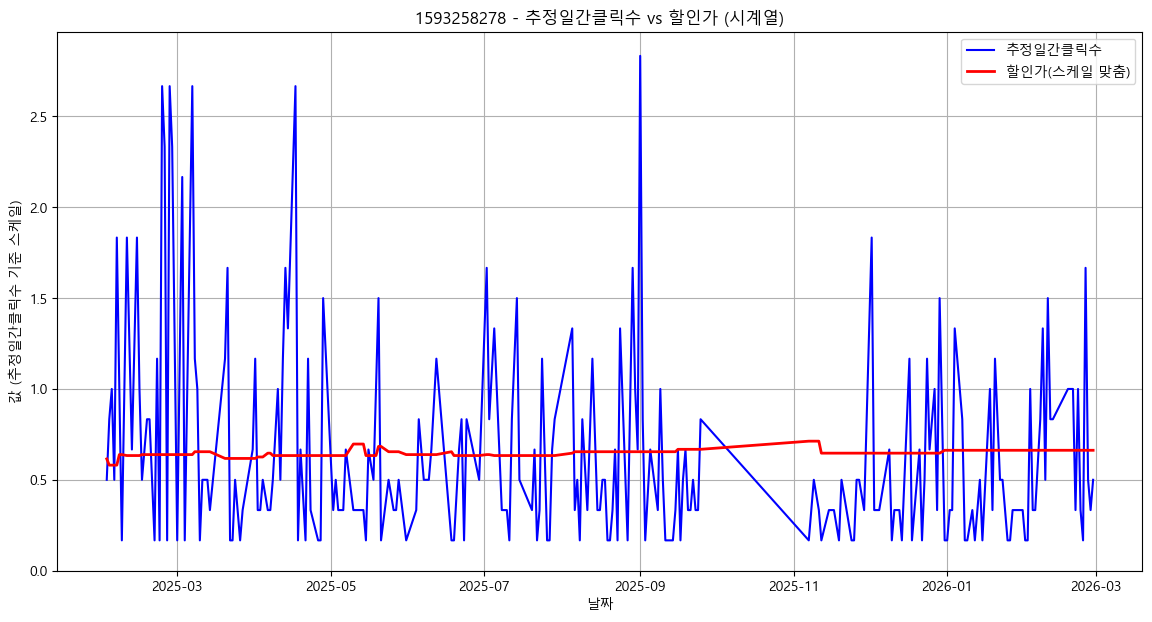

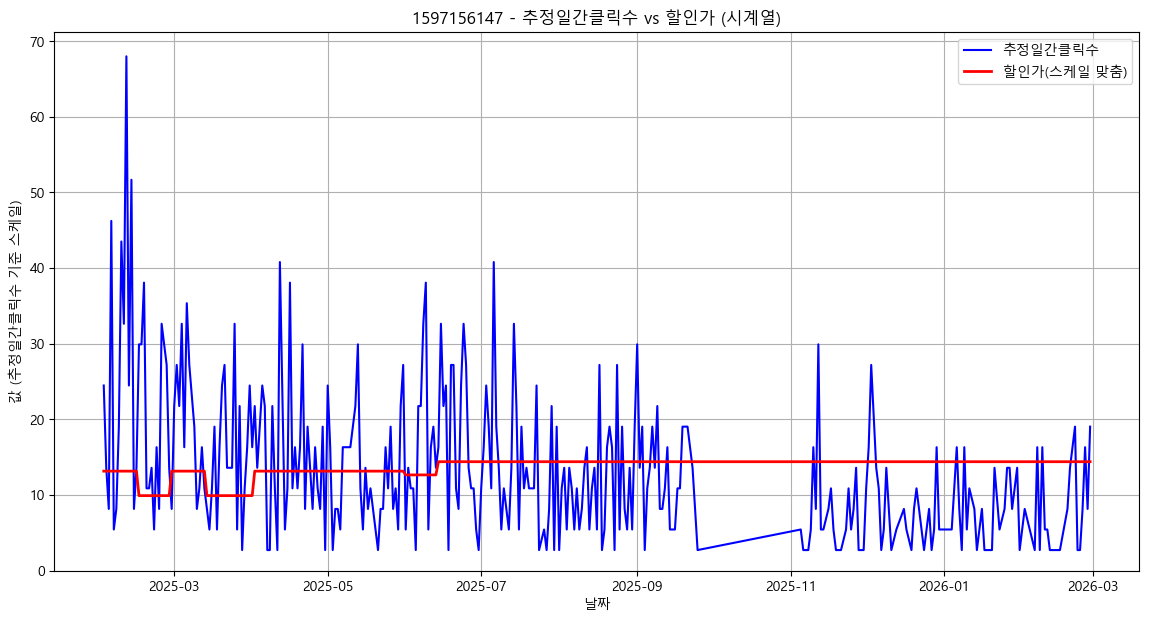

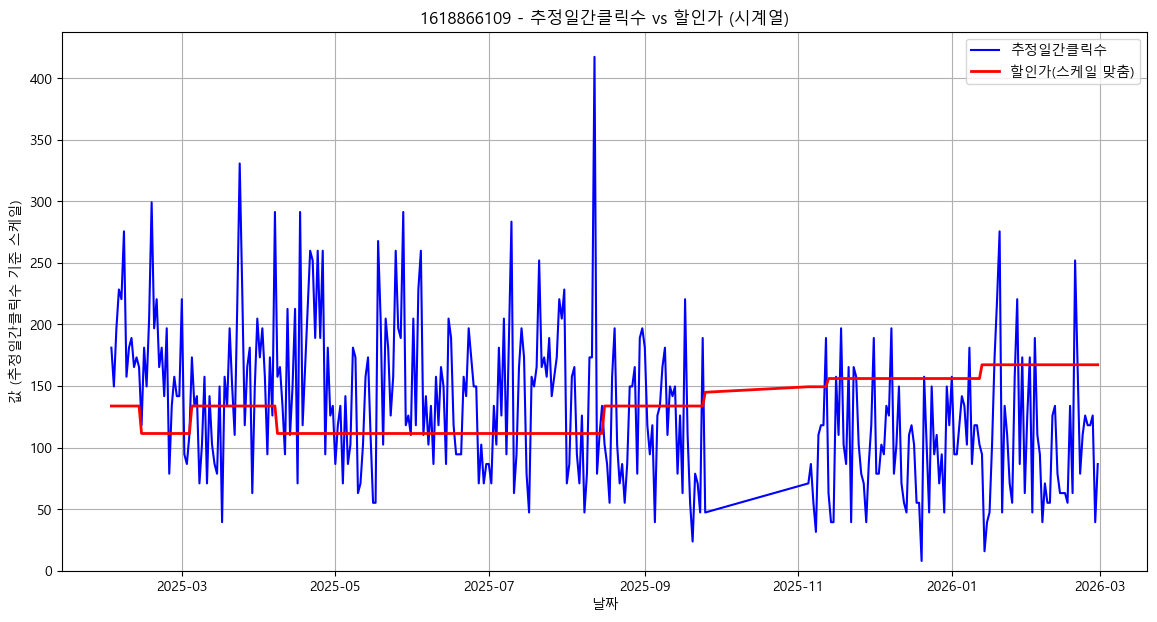

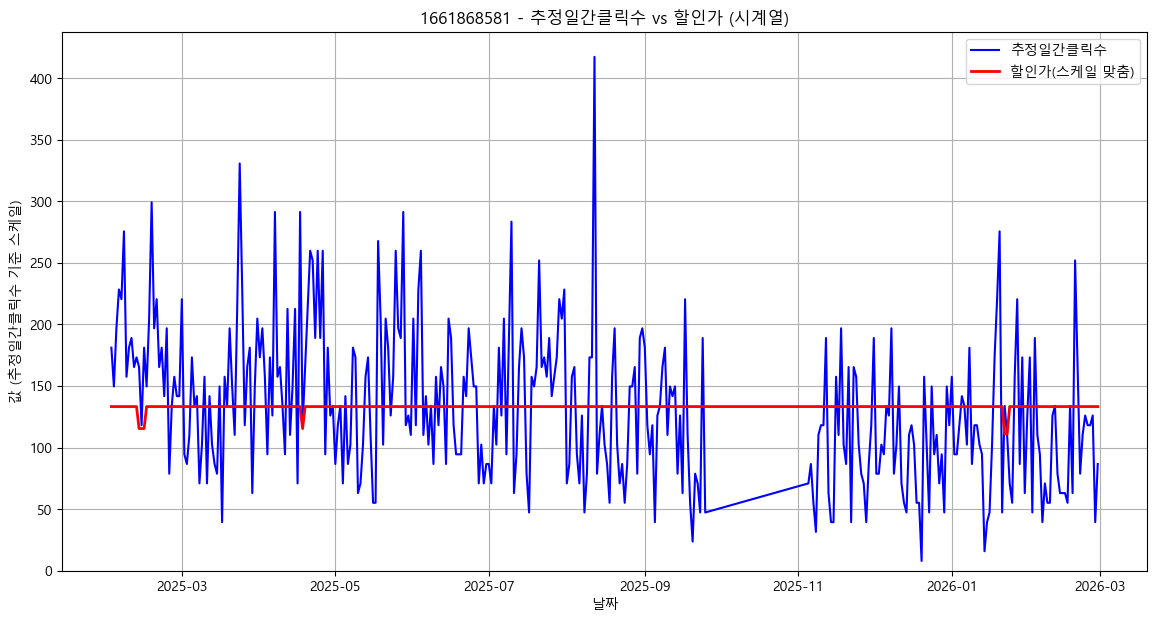

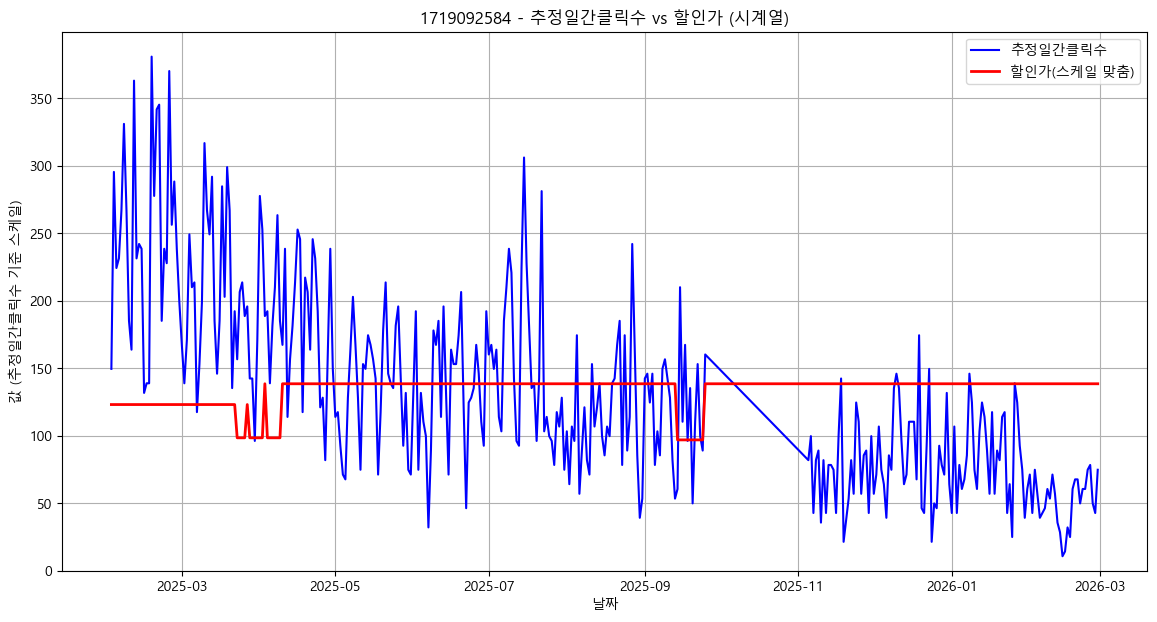

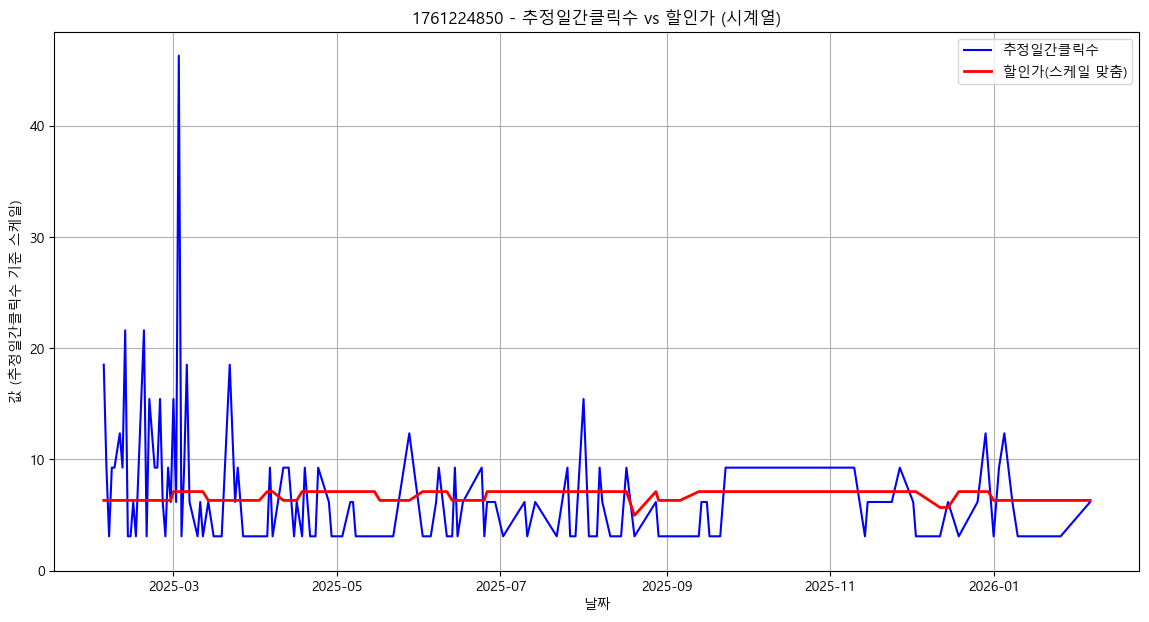

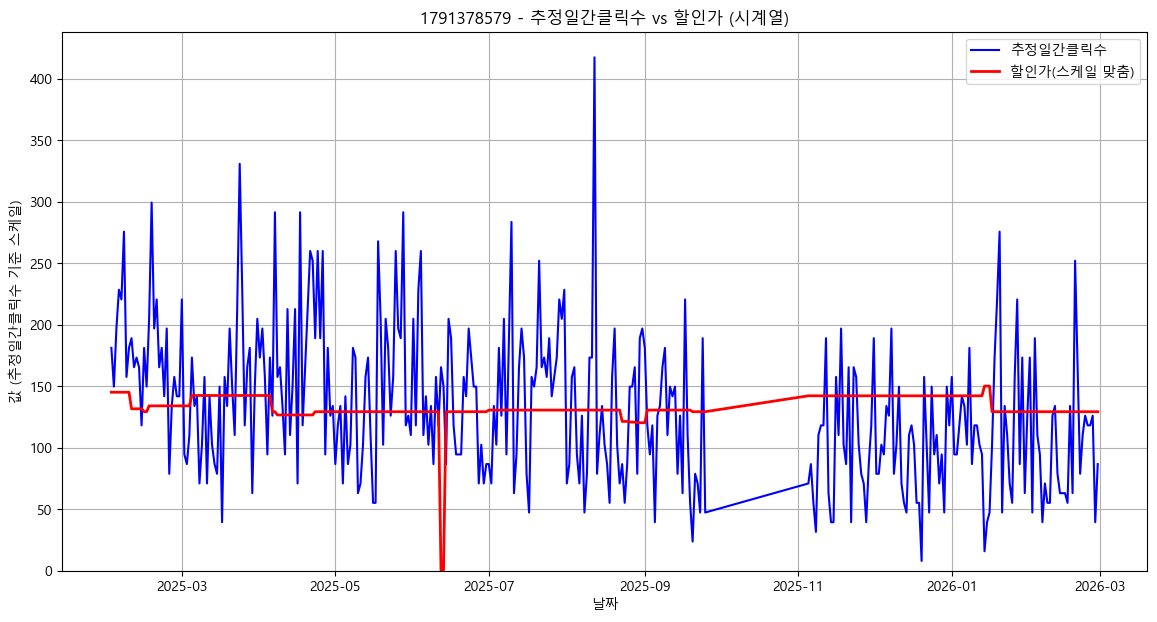

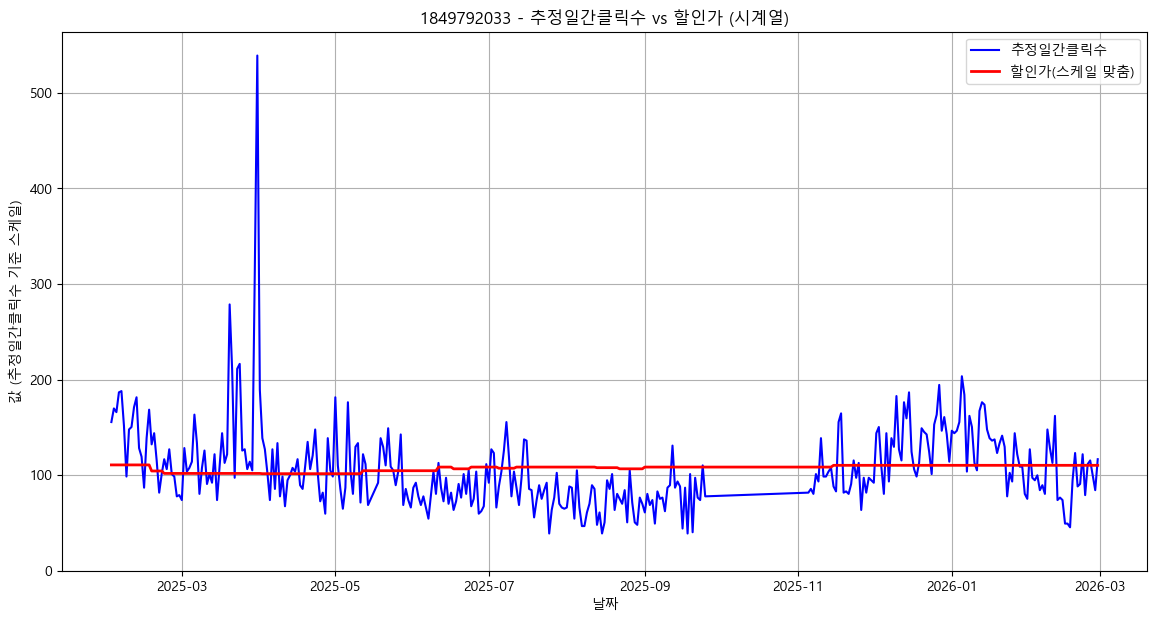

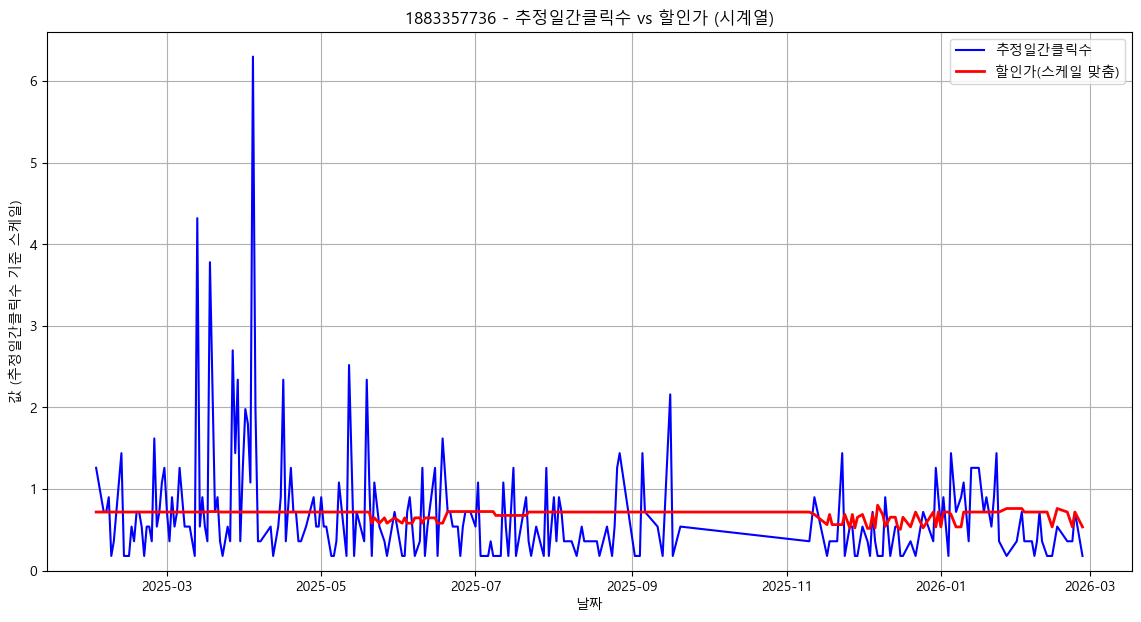

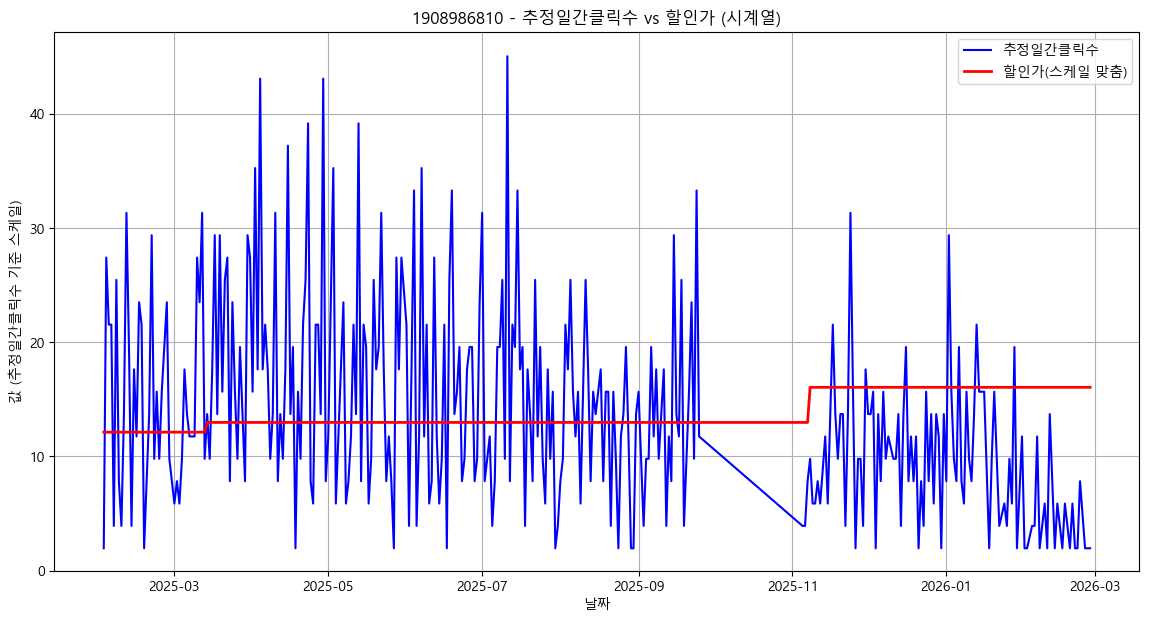

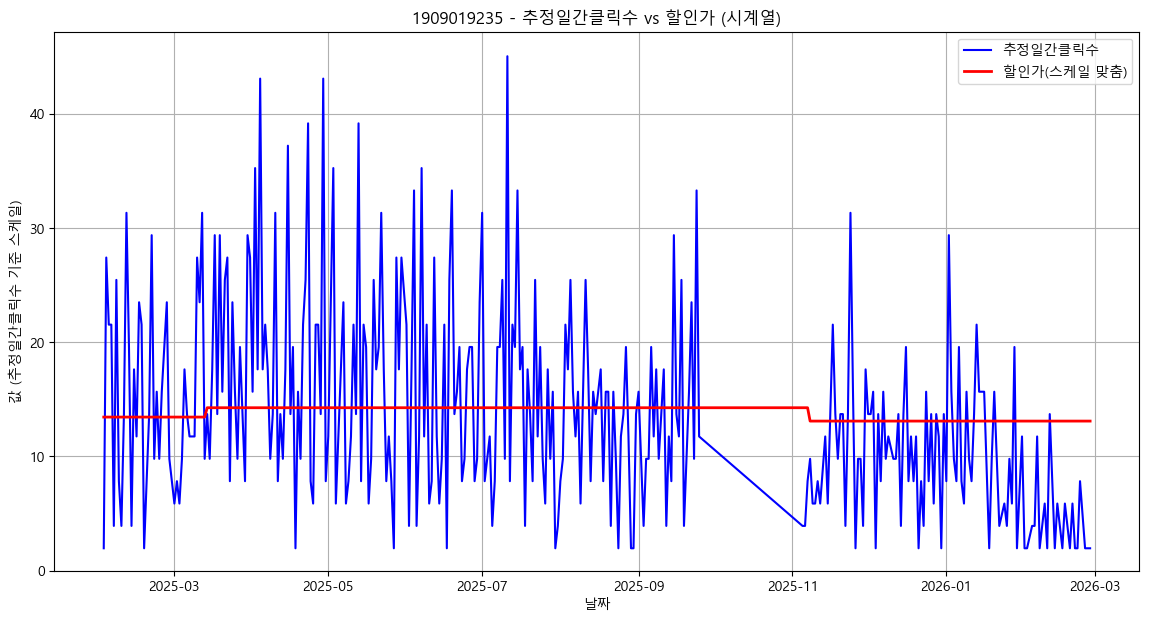

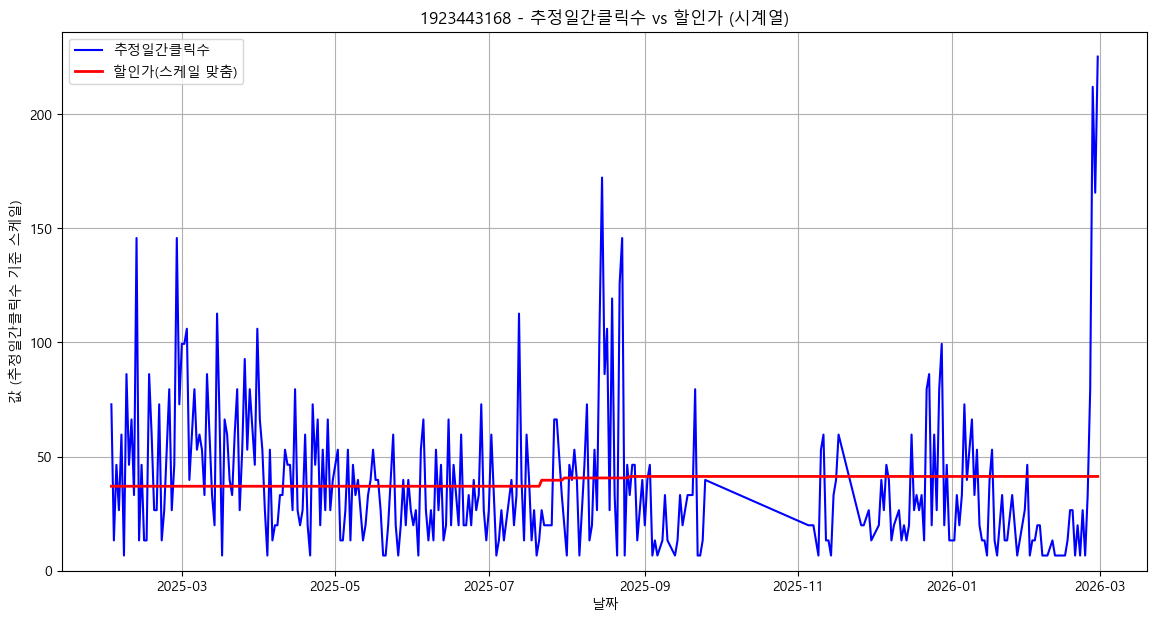

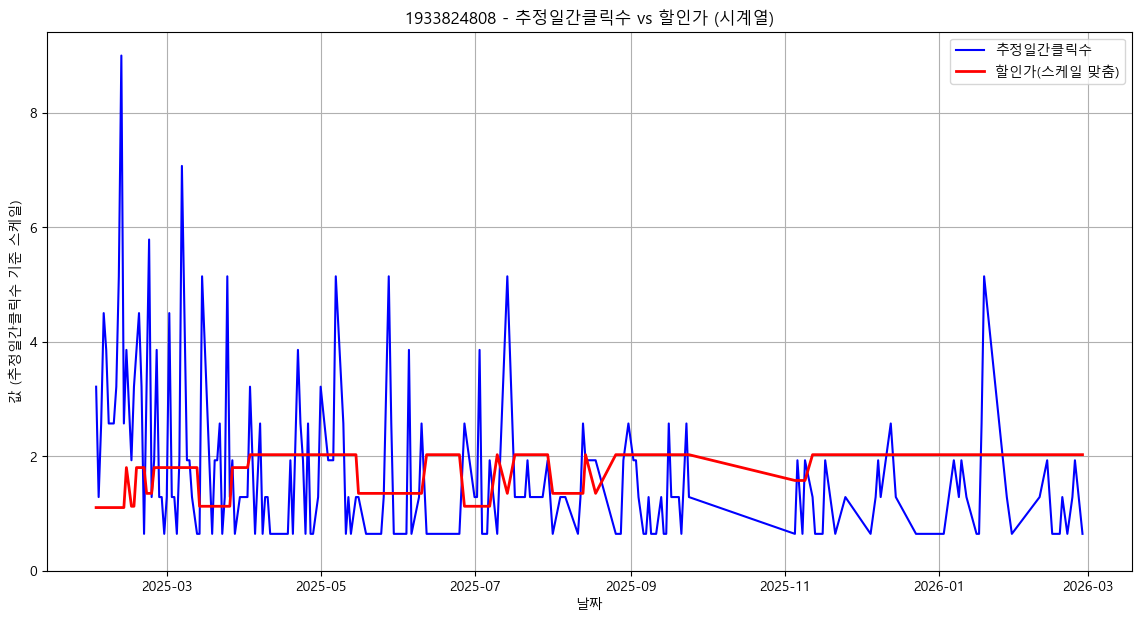

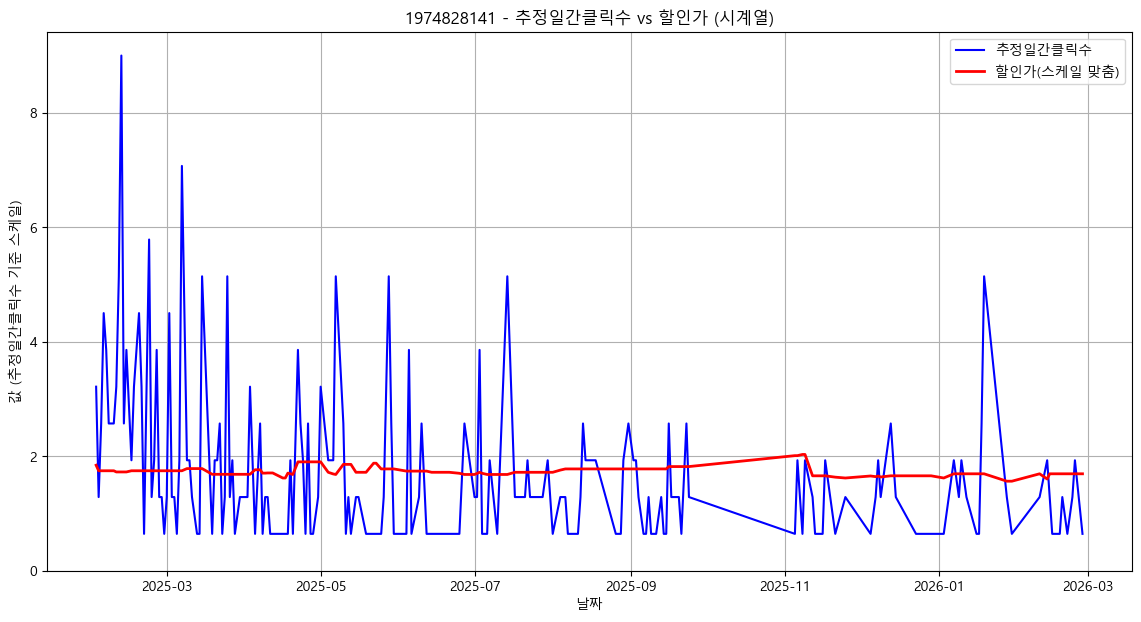

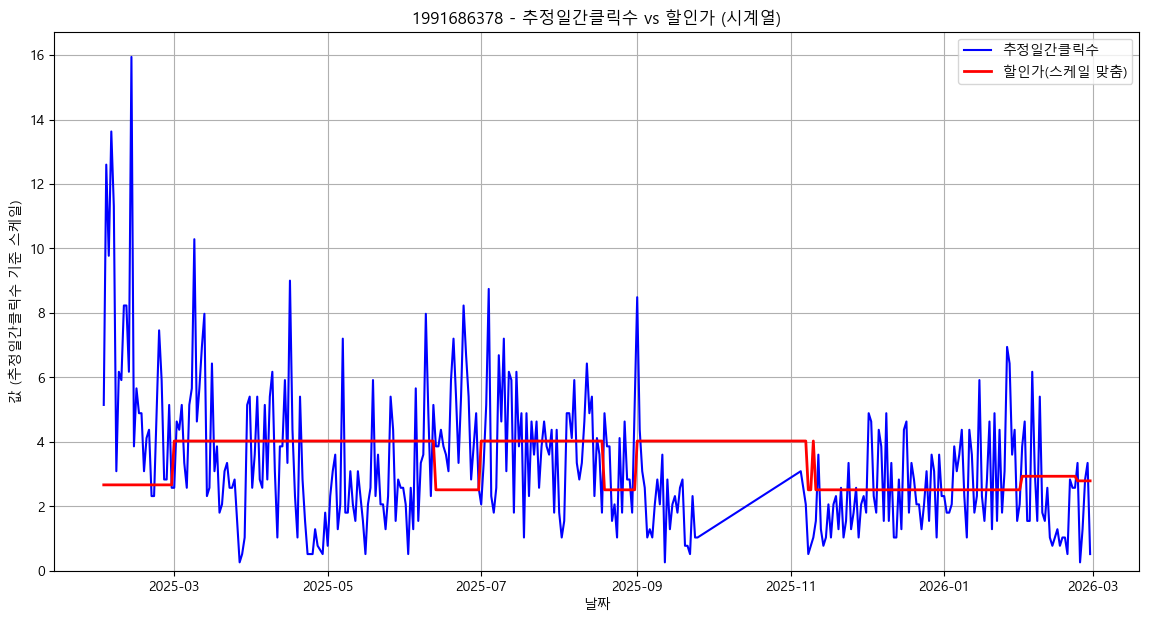

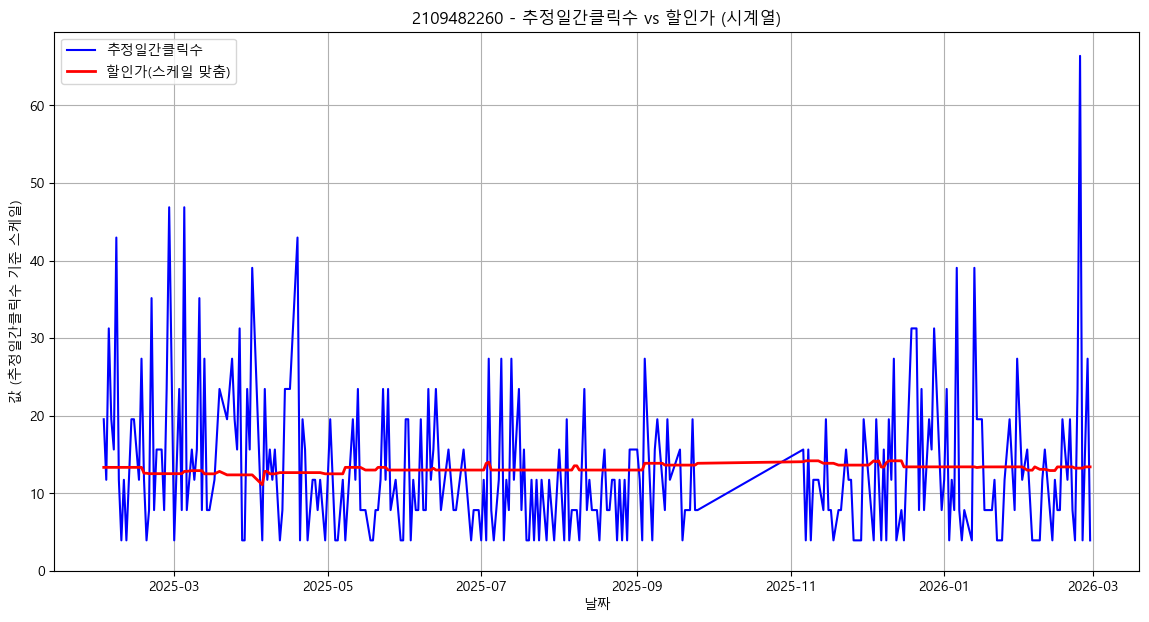

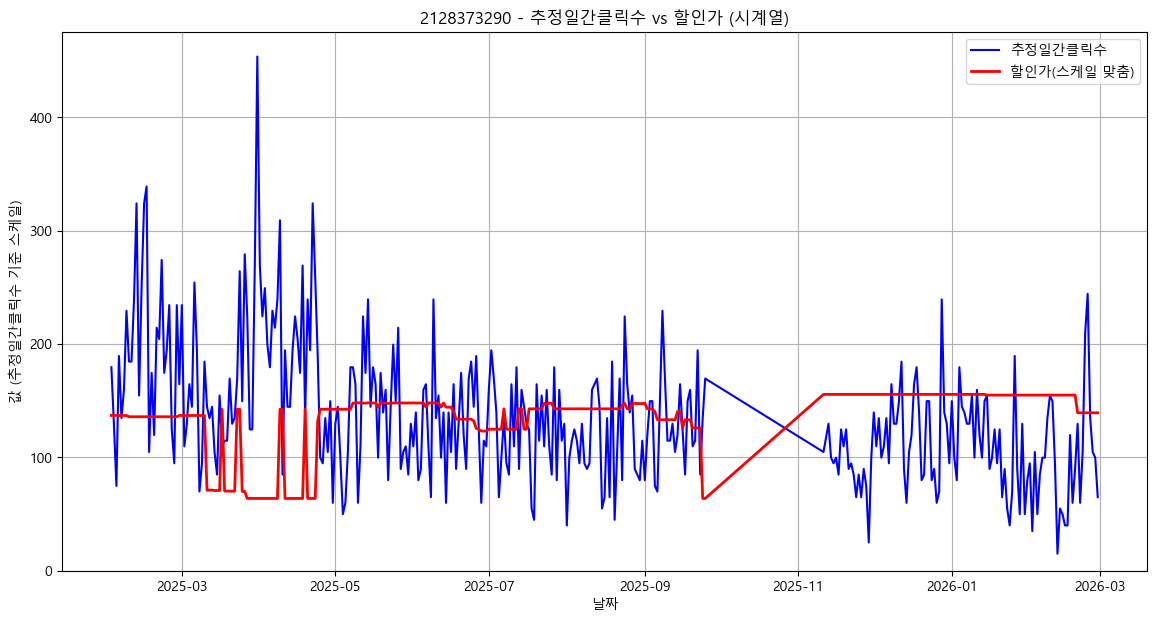

In [ ]:
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv("../data/train_dataset.csv", encoding="utf-8-sig")
df["collect_day"] = pd.to_datetime(df["collect_day"])

# 숫자형 변환
df["추정일간클릭수"] = pd.to_numeric(df["추정일간클릭수"], errors="coerce")
df["discount_price"] = pd.to_numeric(df["discount_price"], errors="coerce")

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# ✅ 상품별 시계열 그래프 (검색량 vs 할인가)
for name, group in df.groupby("good_id"):
    plt.figure(figsize=(14,7))
    
    # 스케일 맞추기: 할인가를 검색량 평균에 맞춰서 조정
    avg_search = group["추정일간클릭수"].mean()
    avg_discount = group["discount_price"].mean()
    scale_factor = avg_search / avg_discount if avg_discount != 0 else 1
    scaled_discount = group["discount_price"] * scale_factor
    
    # 추정일간클릭수 (원래 값 그대로)
    plt.plot(group["collect_day"], group["추정일간클릭수"], label="추정일간클릭수", color="blue")
    
    # 할인가 (스케일 맞춤)
    plt.plot(group["collect_day"], scaled_discount, label="할인가(스케일 맞춤)", color="red", linewidth=2)
    
    plt.title(f"{name} - 추정일간클릭수 vs 할인가 (시계열)")
    plt.xlabel("날짜")
    plt.ylabel("값 (추정일간클릭수 기준 스케일)")
    plt.legend()
    plt.grid(True)
    plt.ylim(bottom=0)  # ✅ y축 하한을 0으로 설정
    plt.show()